# Taller B4-T1 — Diseño de Redes Confiables (Justicia e Incertidumbre)


## 0. Configuración del entorno

Importamos las librerías, fijamos las **semillas aleatorias** (para que los
resultados sean reproducibles) y preparamos las carpetas donde guardaremos las figuras.

In [125]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [126]:
# Si faltara alguna librería, se podría instalar descomentando la siguiente línea:
# !pip install -r ../requirements.txt

# --- Silenciar mensajes internos de TensorFlow para que la salida quede limpia ---
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# --- Librerías de datos y gráficas ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Librerías de Machine Learning ---
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             confusion_matrix, f1_score, ConfusionMatrixDisplay)

# --- Reproducibilidad: fijamos TODAS las semillas a 42 ---
SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)
keras.utils.set_random_seed(SEMILLA)

# --- Comprobamos versiones (deben ser Keras 3 con backend tensorflow) ---
print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("Backend   :", keras.backend.backend())

TensorFlow: 2.21.0
Keras     : 3.14.1
Backend   : tensorflow


In [127]:
# --- Localizamos la raíz del proyecto y creamos la carpeta de figuras ---

cwd = os.getcwd()
BASE_DIR = os.path.dirname(cwd) if os.path.basename(cwd) == "notebooks" else cwd  # raíz del repo

# Carpeta donde guardaremos TODAS las figuras en PNG
FIG_DIR = os.path.join(BASE_DIR, "reports", "figuras")
os.makedirs(FIG_DIR, exist_ok=True)

# --- Buscamos el CSV en varias rutas posibles y nos quedamos con la primera que exista ---
candidatos = [
    os.path.join(BASE_DIR, "application_train.csv"),       # opción 1: en la raíz del repo
    os.path.join(BASE_DIR, "data", "application_train.csv"),  # opción 2: en una carpeta 'data'
    "/mnt/user-data/uploads/application_train.csv",        # opción 3: ruta de subida (este entorno)
    "application_train.csv",                               # opción 4: en la carpeta actual
]
CSV_PATH = next((p for p in candidatos if os.path.exists(p)), candidatos[0])  # el primero que exista

print("Raíz del proyecto :", BASE_DIR)     # mostramos dónde se guardará todo
print("Carpeta de figuras:", FIG_DIR)      # confirmamos la carpeta de figuras
print("CSV de datos      :", CSV_PATH)     # confirmamos qué fichero de datos usaremos

Raíz del proyecto : c:\Users\Natalia\workplace\taller-aml-miax
Carpeta de figuras: c:\Users\Natalia\workplace\taller-aml-miax\reports\figuras
CSV de datos      : c:\Users\Natalia\workplace\taller-aml-miax\data\application_train.csv


## Bloque 1 — Carga del CSV y Análisis Exploratorio (EDA)

El CSV completo pesa ~159 MB. Para no cargarlo entero usamos `usecols` y leemos
**solo 9 columnas**: la variable objetivo (`TARGET`), la variable sensible
(`CODE_GENDER`) y las variables financieras / de fuentes externas.

In [128]:
# --- Definimos las 9 columnas que vamos a leer ---
COLS = [
    "TARGET",            # variable objetivo: 1 = dificultades de pago, 0 = pagó a tiempo
    "CODE_GENDER",       # variable sensible: género del solicitante (M/F)
    "AMT_INCOME_TOTAL",  # ingresos totales del cliente
    "AMT_CREDIT",        # importe del crédito concedido
    "AMT_ANNUITY",       # cuota anual (anualidad) que paga el cliente
    "DAYS_BIRTH",        # edad en días NEGATIVOS respecto a hoy (luego la pasaremos a años)
    "EXT_SOURCE_1",      # puntuación de una fuente externa 1 (tiene MUCHOS nulos)
    "EXT_SOURCE_2",      # puntuación de una fuente externa 2
    "EXT_SOURCE_3",      # puntuación de una fuente externa 3 (bastantes nulos)
]

# --- Leemos el CSV quedándonos solo con esas columnas ---
df_eda = pd.read_csv(CSV_PATH, usecols=COLS)   # 'df_eda' es la tabla para el análisis exploratorio

# --- Mostramos tamaño y primeras filas para hacernos una idea de los datos ---
print("Dimensiones (filas, columnas):", df_eda.shape)
df_eda.head()

Dimensiones (filas, columnas): (307511, 9)


,TARGET,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_BIRTH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,M,202500.0,406597.5,24700.5,-9461,0.083037,0.262949,0.139376
1,0,F,270000.0,1293502.5,35698.5,-16765,0.311267,0.622246,NaN
2,0,M,67500.0,135000.0,6750.0,-19046,NaN,0.555912,0.729567
3,0,F,135000.0,312682.5,29686.5,-19005,NaN,0.650442,NaN
4,0,M,121500.0,513000.0,21865.5,-19932,NaN,0.322738,NaN


### 1.1 Distribución de la variable objetivo (`TARGET`)

Esperamos un **desbalanceo fuerte**: muchos más clientes pagaron a tiempo (0)
que tuvieron problemas (1).

Conteo por clase:
 {0: 282686, 1: 24825}
Porcentaje por clase:
 {0: 91.93, 1: 8.07}


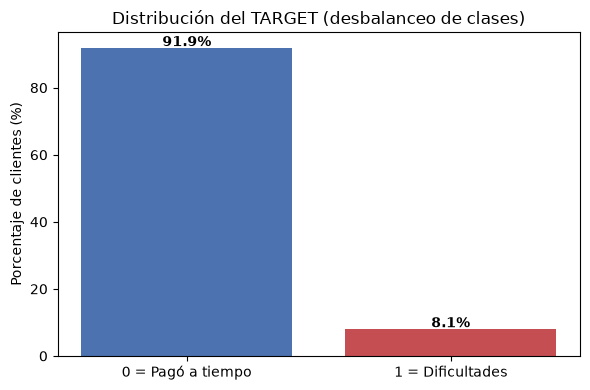

In [129]:
# --- Contamos cuántos 0 y cuántos 1 hay en TARGET, y su porcentaje ---
conteo = df_eda["TARGET"].value_counts().sort_index()                 # nº de casos de cada clase (0 y 1)
porcentaje = df_eda["TARGET"].value_counts(normalize=True).sort_index() * 100  # lo mismo pero en %

print("Conteo por clase:\n", conteo.to_dict())          # diccionario {0: ..., 1: ...}
print("Porcentaje por clase:\n", porcentaje.round(2).to_dict())  # porcentajes redondeados

# --- Gráfico de barras con el porcentaje de cada clase ---
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(["0 = Pagó a tiempo", "1 = Dificultades"],
                porcentaje.values,
                color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Porcentaje de clientes (%)")
ax.set_title("Distribución del TARGET (desbalanceo de clases)")
for b, p in zip(barras, porcentaje.values):
    ax.text(b.get_x() + b.get_width()/2, p + 0.5,
            f"{p:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_target_distribucion.png"), dpi=150, bbox_inches="tight")  # guardamos PNG
plt.show()

### 1.2 Porcentaje de valores nulos por columna

Las fuentes externas `EXT_SOURCE_*` tienen muchos ausentes. Esto será **clave**
para la parte de incertidumbre (que haremos más adelante).

% de valores nulos por columna:
EXT_SOURCE_1        56.38
EXT_SOURCE_3        19.83
EXT_SOURCE_2         0.21
AMT_ANNUITY          0.00
TARGET               0.00
AMT_CREDIT           0.00
AMT_INCOME_TOTAL     0.00
CODE_GENDER          0.00
DAYS_BIRTH           0.00
dtype: float64


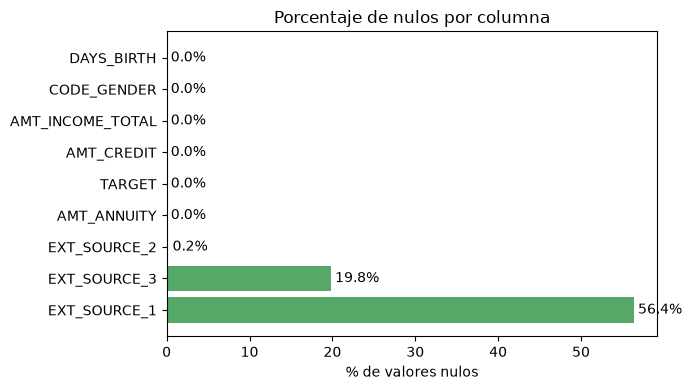

In [130]:
# --- Calculamos el % de valores nulos (vacíos) de cada columna ---
nulos_pct = (df_eda.isna().mean() * 100).sort_values(ascending=False)  # % de nulos, de mayor a menor
print("% de valores nulos por columna:")
print(nulos_pct.round(2))

# --- Gráfico de barras horizontales con el % de nulos ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(nulos_pct.index, nulos_pct.values, color="#55A868")
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de nulos por columna")
for i, v in enumerate(nulos_pct.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_nulos_por_columna.png"), dpi=150, bbox_inches="tight")
plt.show()

### 1.3 Histogramas de las variables financieras y de `EXT_SOURCE_*`

Las variables de dinero tienen valores extremos (algún cliente con ingresos
gigantes), así que para que el histograma se vea bien recortamos la vista al
**percentil 99** (solo para dibujar; no modificamos los datos).

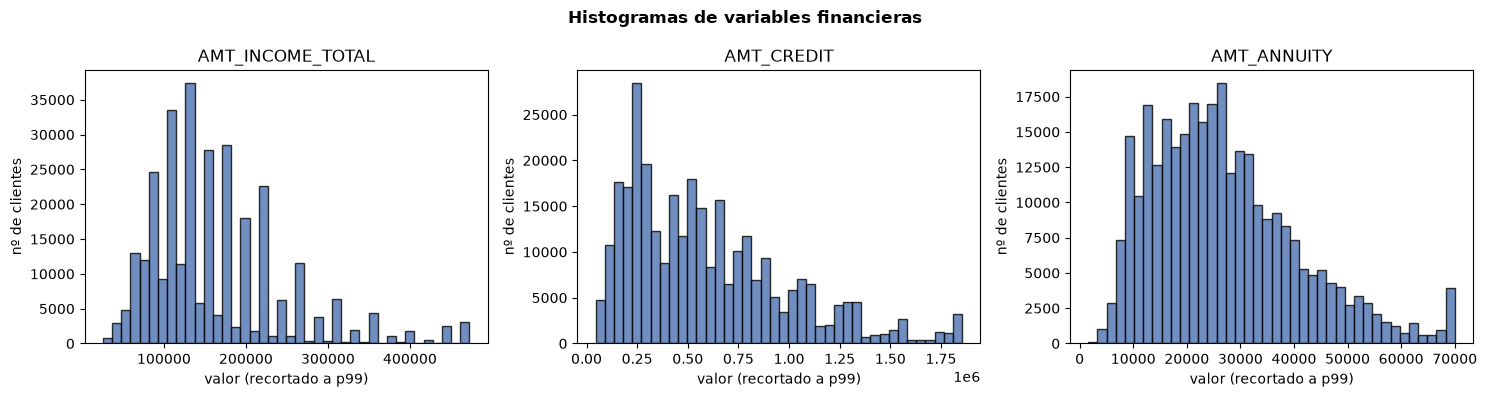

In [131]:
# --- Histogramas de las 3 variables financieras (ingreso, crédito, anualidad) ---
financieras = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]   # columnas de dinero
fig, axes = plt.subplots(1, 3, figsize=(15, 4))                   # 1 fila y 3 columnas de gráficas
for ax, col in zip(axes, financieras):                           # recorremos cada variable y su hueco
    tope = df_eda[col].quantile(0.99)                            # percentil 99 para recortar la cola larga
    ax.hist(df_eda[col].clip(upper=tope), bins=40,               # histograma recortando valores extremos
            color="#4C72B0", edgecolor="black", alpha=0.8)        # color y borde de las barras
    ax.set_title(col)                                            # título = nombre de la variable
    ax.set_xlabel("valor (recortado a p99)")                     # eje X
    ax.set_ylabel("nº de clientes")                              # eje Y
plt.suptitle("Histogramas de variables financieras", fontweight="bold")  # título general
plt.tight_layout()                                               # ajustamos márgenes
plt.savefig(os.path.join(FIG_DIR, "03_histogramas_financieras.png"), dpi=150, bbox_inches="tight")  # PNG
plt.show()                                                       # mostramos

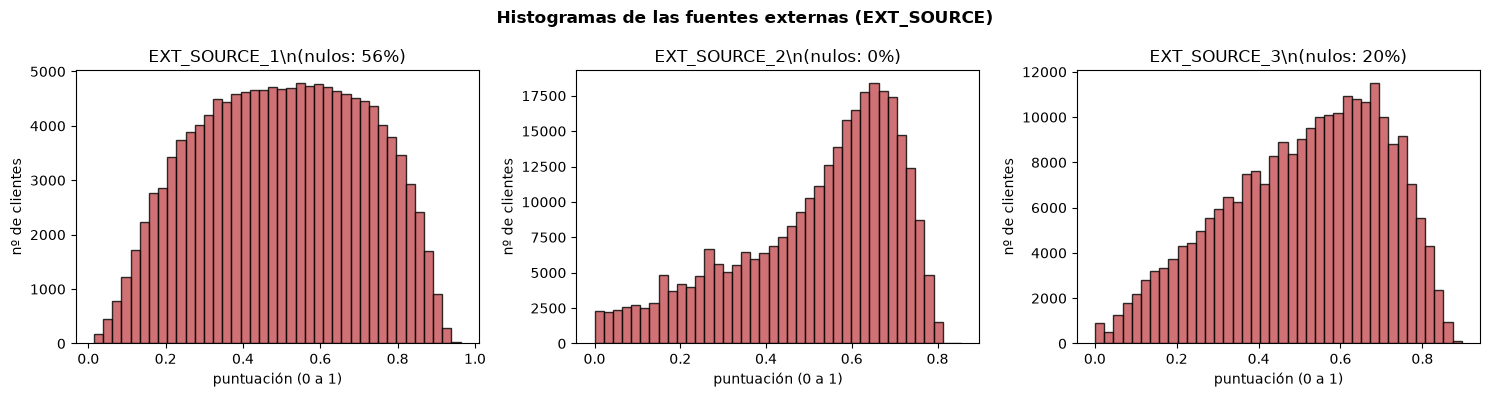

In [132]:
# --- Histogramas de las 3 fuentes externas EXT_SOURCE_1/2/3 (valores entre 0 y 1) ---
ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ext):
    ax.hist(df_eda[col].dropna(), bins=40,
            color="#C44E52", edgecolor="black", alpha=0.8)
    ax.set_title(f"{col}\\n(nulos: {df_eda[col].isna().mean()*100:.0f}%)")
    ax.set_xlabel("puntuación (0 a 1)")
    ax.set_ylabel("nº de clientes")
plt.suptitle("Histogramas de las fuentes externas (EXT_SOURCE)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_histogramas_ext_source.png"), dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Matriz de correlación (heatmap)

Vemos qué variables están relacionadas entre sí y con el `TARGET`. Para que las
correlaciones tengan sentido, primero pasamos el género a número y la edad a años.

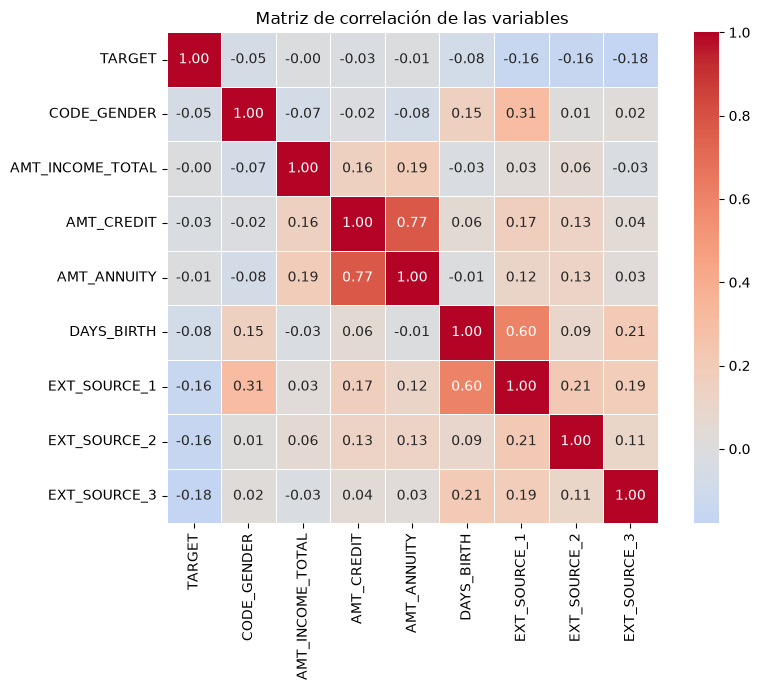

In [133]:
# --- Preparamos una copia numérica para calcular correlaciones ---
df_corr = df_eda.copy()
df_corr["CODE_GENDER"] = df_corr["CODE_GENDER"].map({"M": 0, "F": 1}).fillna(0)
df_corr["DAYS_BIRTH"] = np.abs(df_corr["DAYS_BIRTH"]) / 365
# --- Calculamos la matriz de correlación entre todas las columnas ---
matriz_corr = df_corr.corr() # correlación de Pearson (-1 a 1)

# --- Dibujamos el heatmap (mapa de calor) de correlaciones ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de correlación de las variables")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_heatmap_correlacion.png"), dpi=150, bbox_inches="tight")
plt.show()

### 1.5 Matriz scatter/histograma (estilo del profesor) sobre una muestra

Reproducimos la rejilla de dispersión + histogramas del notebook del profesor,
pero sobre una **muestra aleatoria de 5.000 filas**, porque con 307.000 filas
sería lentísimo y los puntos se solaparían.

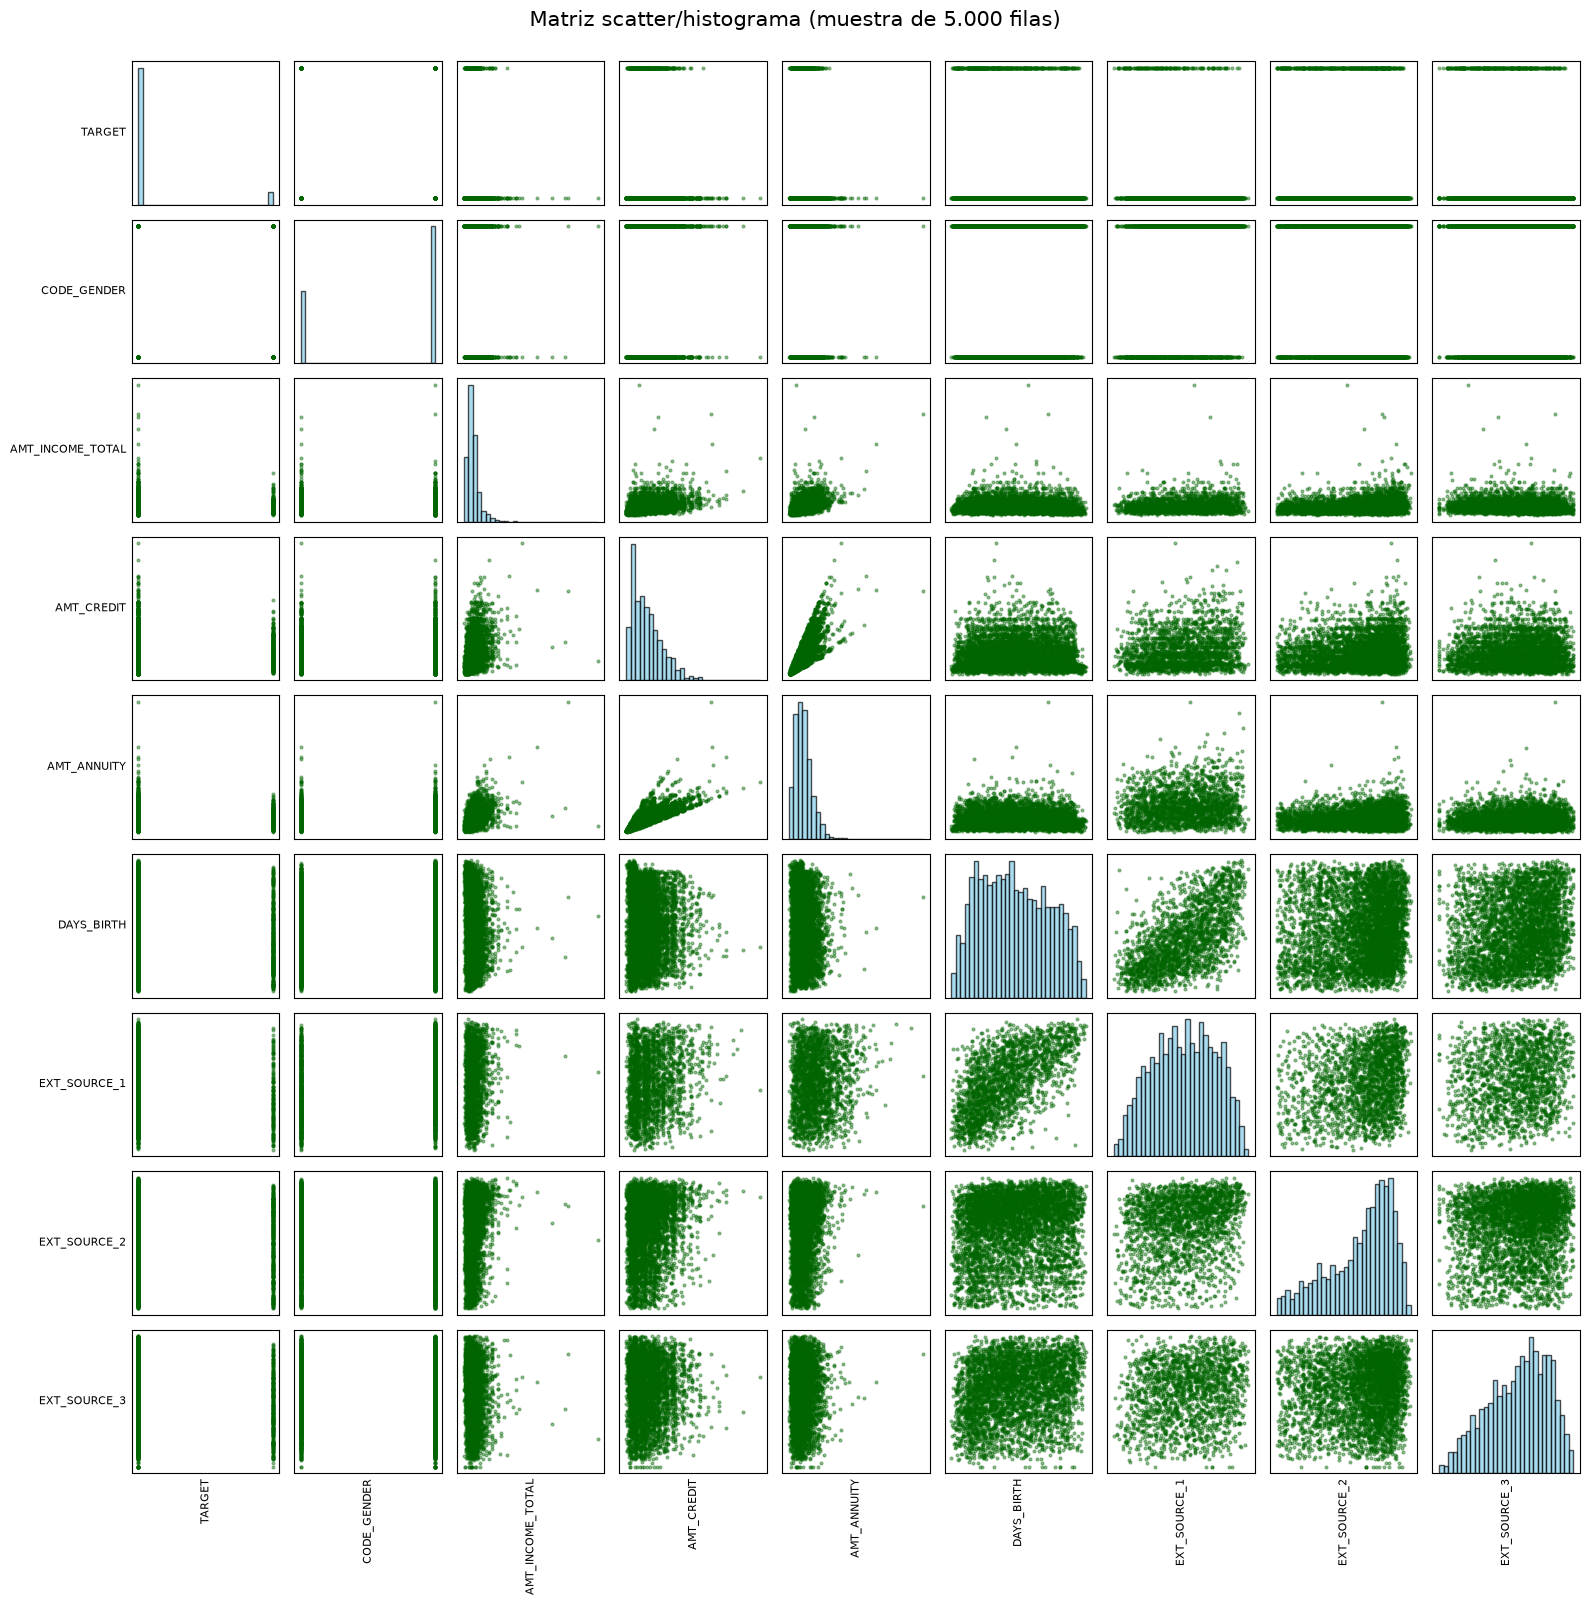

In [134]:
# --- Tomamos una muestra aleatoria de 5.000 filas (reproducible con la semilla) ---
muestra = df_corr.sample(n=5000, random_state=SEMILLA)
datos = muestra.values
nombres = list(muestra.columns)
n = datos.shape[1]

# --- Creamos una rejilla n x n de mini-gráficas (igual estilo que el profe) ---
fig, axes = plt.subplots(n, n, figsize=(16, 16))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i == j:
            ax.hist(datos[:, i], bins=30, color="skyblue", edgecolor="black", alpha=0.7)
        else:
            ax.scatter(datos[:, j], datos[:, i], s=4, alpha=0.4, color="darkgreen")
        if i == n - 1:
            ax.set_xlabel(nombres[j], rotation=90, fontsize=8)
        if j == 0:
            ax.set_ylabel(nombres[i], rotation=0, ha="right", va="center", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Matriz scatter/histograma (muestra de 5.000 filas)", y=1.0, fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_matriz_scatter_profe.png"), dpi=120, bbox_inches="tight")
plt.show()

### 1.6 Hallazgos clave del EDA

- **Desbalanceo fuerte del target:** solo ~**8 %** de los clientes son de la clase 1
  (dificultades de pago) frente a ~92 % de la clase 0. Habrá que compensarlo al entrenar
  (usaremos `class_weight`) y **no** fiarnos solo de la *accuracy*.
- **Muchos nulos en las fuentes externas:** `EXT_SOURCE_1` tiene **~56 %** de valores
  ausentes y `EXT_SOURCE_3` **~20 %**. Son justo las variables más informativas para
  predecir el impago, por lo que la calidad de su imputación será **clave para la
  incertidumbre** (parte que abordaremos más adelante).
- **Variables financieras muy sesgadas:** ingresos, crédito y anualidad tienen colas
  muy largas (pocos clientes con valores enormes), de ahí que las escalemos antes de entrenar.

## Bloque 2 y 3 — Preprocesado + split *train / val / test*

Partimos de la función `load_home_credit_data` del esqueleto del profesor y le
hacemos **tres mejoras**:

1. **Arreglamos un bug:** `AMT_ANNUITY` tiene ~12 valores nulos que el profesor no
   imputa y que **rompen el `StandardScaler`**. Los imputamos con la mediana.
2. **Pasamos de 2 a 3 particiones:** primero `train`/`temp` 80/20 y luego partimos
   ese 20 % en `val`/`test` al 50/50 (igual que en el ejemplo *Adult*) → **80/10/10**.
3. **Guardamos una copia SIN ESCALAR** de las columnas financieras (ingreso, crédito,
   anualidad), porque la capa custom necesitará calcular *ratios económicos reales*
   (un ratio sobre datos escalados centrados en 0 no tiene sentido, ver Bloque 4).

La variable sensible `s = CODE_GENDER` se mantiene **aparte** (para la futura FAIR Loss)
y también dentro de `X`, tal como hace el profesor.

In [135]:
def load_home_credit_data(file_path):
    """Carga y preprocesa el dataset Home Credit con split train/val/test (80/10/10).

    Devuelve los conjuntos escalados, la variable sensible alineada y una copia
    SIN escalar de las columnas financieras (para la capa custom)."""

    # --- 1) Leemos solo las 9 columnas relevantes ---
    cols = ["TARGET", "CODE_GENDER", "AMT_INCOME_TOTAL", "AMT_CREDIT",
            "AMT_ANNUITY", "DAYS_BIRTH", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    df = pd.read_csv(file_path, usecols=cols)            # tabla con las 9 columnas

    # --- 2) Preprocesado básico (igual que el profesor) ---
    df["CODE_GENDER"] = df["CODE_GENDER"].map({"M": 0, "F": 1}).fillna(0)  # género -> 0/1 (los 'XNA' -> 0)
    df["DAYS_BIRTH"] = np.abs(df["DAYS_BIRTH"]) / 365     # edad: días negativos -> años positivos
    for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:  # recorremos las fuentes externas
        df[col] = df[col].fillna(df[col].median())        # rellenamos sus nulos con la MEDIANA

    # --- 3) ARREGLO DEL BUG: AMT_ANNUITY tiene ~12 nulos que el profe no imputa ---
    df["AMT_ANNUITY"] = df["AMT_ANNUITY"].fillna(df["AMT_ANNUITY"].median())  # imputamos con la mediana

    # --- 4) Comprobación de seguridad: NO debe quedar ningún nulo ---
    n_nulos = int(df.isna().sum().sum())                  # contamos todos los nulos que quedan
    assert n_nulos == 0, f"Aún quedan {n_nulos} nulos"    # si quedara alguno, paramos con un aviso
    print("Nulos restantes tras el preprocesado:", n_nulos)  # debe imprimir 0

    # --- 5) Separamos variables: X (entradas), y (objetivo) y s (sensible) ---
    X = df.drop(columns=["TARGET"])                       # X = todas las columnas menos el objetivo
    y = df["TARGET"]                                      # y = la columna objetivo
    s = df["CODE_GENDER"]                                 # s = variable sensible (género), guardada aparte

    # --- 6) Copia SIN ESCALAR de las columnas financieras (para la capa custom) ---
    cols_fin = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]  # ingreso, crédito, anualidad
    X_fin = df[cols_fin]                                  # estos valores quedan en sus unidades reales (€)

    # --- 7) Primer split 80/20: separamos un 20% temporal que luego dividiremos ---
    (X_tr, X_tmp, y_tr, y_tmp, s_tr, s_tmp,
     Xf_tr, Xf_tmp) = train_test_split(X, y, s, X_fin,    # partimos X, y, s y X_fin A LA VEZ (mismos índices)
                                       test_size=0.2, random_state=42)

    # --- 8) Segundo split 50/50 sobre ese 20%: mitad validación, mitad test (-> 10% y 10%) ---
    (X_val, X_te, y_val, y_te, s_val, s_te,
     Xf_val, Xf_te) = train_test_split(X_tmp, y_tmp, s_tmp, Xf_tmp,
                                       test_size=0.5, random_state=42)

    # --- 9) Escalado: el StandardScaler SE AJUSTA SOLO con train, y se aplica a val y test ---
    scaler = StandardScaler()                             # objeto que resta la media y divide por la desviación
    X_tr_s  = scaler.fit_transform(X_tr)                  # AJUSTA con train y lo transforma
    X_val_s = scaler.transform(X_val)                     # SOLO transforma validación (sin re-ajustar)
    X_te_s  = scaler.transform(X_te)                      # SOLO transforma test

    # --- 10) Pasamos todo a tipo float32 (lo que prefieren las redes neuronales) ---
    y_tr  = y_tr.values.astype("float32");  y_val = y_val.values.astype("float32");  y_te = y_te.values.astype("float32")
    s_tr  = s_tr.values.astype("float32");  s_val = s_val.values.astype("float32");  s_te = s_te.values.astype("float32")
    Xf_tr = Xf_tr.values.astype("float32"); Xf_val = Xf_val.values.astype("float32"); Xf_te = Xf_te.values.astype("float32")

    # --- 11) Devolvemos todo empaquetado en tres "bolsas": train, val y test ---
    return (
        (X_tr_s,  y_tr,  s_tr,  Xf_tr),     # conjunto de entrenamiento
        (X_val_s, y_val, s_val, Xf_val),    # conjunto de validación
        (X_te_s,  y_te,  s_te,  Xf_te),     # conjunto de test
        scaler,                              # devolvemos el scaler por si se necesita después
    )

In [136]:
# --- Usamos la función para obtener los tres conjuntos ya preparados ---
(train, val, test, scaler) = load_home_credit_data(CSV_PATH)   # llamamos a la función con la ruta del CSV

# --- Desempaquetamos cada bolsa en sus piezas para usarlas cómodamente ---
X_train, y_train, s_train, Xfin_train = train   # entrenamiento: X escalado, y, s, X financiero sin escalar
X_val,   y_val,   s_val,   Xfin_val   = val     # validación
X_test,  y_test,  s_test,  Xfin_test  = test    # test

Nulos restantes tras el preprocesado: 0


In [137]:
# --- Imprimimos los SHAPES (filas, columnas) para verificar que todo cuadra ---
print("== ENTRENAMIENTO ==")
print("X_train:", X_train.shape, "| y_train:", y_train.shape, "| s_train:", s_train.shape, "| Xfin_train:", Xfin_train.shape)
print("== VALIDACIÓN ==")
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape,   "| s_val  :", s_val.shape,   "| Xfin_val  :", Xfin_val.shape)
print("== TEST ==")
print("X_test :", X_test.shape,  "| y_test :", y_test.shape,  "| s_test :", s_test.shape,  "| Xfin_test :", Xfin_test.shape)

# --- Verificaciones de seguridad antes de entrenar ---
print("\\nNaN en X_train:", int(np.isnan(X_train).sum()),   # NO debe haber ningún NaN (vacío) en los datos
      "| NaN en X_val:", int(np.isnan(X_val).sum()),
      "| NaN en X_test:", int(np.isnan(X_test).sum()))
print("s_train alineado con X_train (misma longitud):",     # comprobamos que la variable sensible está alineada
      X_train.shape[0] == s_train.shape[0])

== ENTRENAMIENTO ==
X_train: (246008, 8) | y_train: (246008,) | s_train: (246008,) | Xfin_train: (246008, 3)
== VALIDACIÓN ==
X_val  : (30751, 8) | y_val  : (30751,) | s_val  : (30751,) | Xfin_val  : (30751, 3)
== TEST ==
X_test : (30752, 8) | y_test : (30752,) | s_test : (30752,) | Xfin_test : (30752, 3)
\nNaN en X_train: 0 | NaN en X_val: 0 | NaN en X_test: 0
s_train alineado con X_train (misma longitud): True


## Bloque 4 — Arquitectura customizada (Punto 1 de la práctica)

### Idea de la capa custom

Implementamos una capa `RatioFinancieroLayer` que, **dentro de la red**:

1. Recibe las columnas financieras **en euros reales** (ingreso, crédito, anualidad).
2. Calcula dos **ratios económicos interpretables**:
   - **DSR** (*debt-service ratio*) = anualidad / ingreso → cuánto del ingreso se va en pagar la cuota.
   - **LTI** (*loan-to-income*) = crédito / ingreso → cuántas veces el ingreso supone el crédito.
3. Aplica una **saturación matemática** sobre esos ratios con una **sigmoide centrada y de
   escala entrenable**: `salida = sigmoide(alpha · (ratio − beta))`. La sigmoide comprime
   cualquier valor al rango acotado **(0, 1)** (la *restricción matemática* que pide el
   enunciado). Tiene **dos parámetros entrenables** por ratio:
   - `alpha` = **pendiente/sensibilidad** de la saturación (cómo de brusco es el corte).
   - `beta`  = **umbral económico** en el que se centra la saturación. La red lo *aprende*,
     de modo que descubre el nivel de endeudamiento a partir del cual el riesgo se dispara
     (lo inicializamos en valores típicos: DSR ≈ 0.3, LTI ≈ 3.0).
4. Ambos pesos están **acotados por un `Constraint` propio** (`CustomClipValue`), igual que
   `CustomClipValue` limita el peso de `ExponentLayer` en el ejemplo *Adult*: `alpha` se
   mantiene en [0.1, 10] (positivo, no se dispara) y `beta` en [0, 30] (umbral no negativo).
   Centrar la sigmoide en `beta` es lo que hace que los ratios **conserven varianza** y sean
   features discriminativas (si no, casi todos saturarían a 0/1 y no aportarían información).

### El problema numérico del ratio (y cómo lo resolvemos)

Tras el `StandardScaler`, ingresos y anualidades quedan **centrados en 0**, así que un ratio
"anualidad / ingreso" directo dividiría entre ~0 (inestable, posibles `NaN`) y además
**perdería su significado económico**.

**Solución elegida (de las tres que permite el enunciado):** usar la **API Funcional con dos
entradas**. La capa custom recibe las columnas financieras **SIN escalar** (positivas y en euros,
así los ratios son reales y estables), mientras que el resto de la red recibe las **8 features
escaladas**. Como el ingreso es siempre > 0 (mínimo ≈ 25.650 €), la división nunca explota;
aun así añadimos un `epsilon` mínimo por seguridad. Es la opción más limpia porque mantiene
intacto el sentido económico del ratio.

In [138]:
# --- CONSTRAINT propio: limita un peso a un rango [min, max] (estilo CustomClipValue del profe) ---
class CustomClipValue(keras.constraints.Constraint):
    """Restringe (recorta) un peso para que se quede entre min_value y max_value."""
    def __init__(self, min_value, max_value):
        self.min_value = min_value          # valor mínimo permitido para el peso
        self.max_value = max_value          # valor máximo permitido para el peso

    def __call__(self, w):                  # Keras llama a esto tras cada actualización del peso
        # keras.ops.clip recorta 'w' para que no salga del rango [min, max]
        return keras.ops.clip(w, self.min_value, self.max_value)

    def get_config(self):                   # permite guardar/cargar la capa con su configuración
        return {"min_value": self.min_value, "max_value": self.max_value}

In [139]:
# --- CAPA CUSTOM: calcula ratios financieros y les aplica una saturación entrenable ---
class RatioFinancieroLayer(keras.layers.Layer):
    """Capa que recibe [ingreso, credito, anualidad] (SIN escalar) y devuelve
    dos ratios económicos saturados con una sigmoide de escala entrenable 'alpha'."""

    def __init__(self, epsilon=1e-3, **kwargs):
        super().__init__(**kwargs)          # inicializa la parte interna de Keras
        self.epsilon = epsilon              # número pequeñito para no dividir nunca entre 0

    def build(self, input_shape):           # se ejecuta una vez, al construir la red: aquí creamos los pesos
        # 'alpha': pendiente/sensibilidad de la saturación (un valor por ratio -> 2 valores).
        # Empieza en 1.0 y queda ACOTADO por nuestro Constraint entre 0.1 y 10.0.
        self.alpha = self.add_weight(
            shape=(2,),                     # 2 valores: uno para DSR y otro para LTI
            initializer="ones",             # valor inicial = 1.0
            constraint=CustomClipValue(0.1, 10.0),  # lo mantenemos en [0.1, 10] (positivo y acotado)
            trainable=True,                 # SÍ se aprende durante el entrenamiento
            name="alpha",                   # nombre del peso (aparecerá en el summary)
        )
        # 'beta': UMBRAL económico donde se centra la saturación (un valor por ratio).
        # Lo inicializamos en valores típicos (DSR~0.3, LTI~3.0) y lo acotamos a no negativo.
        self.beta = self.add_weight(
            shape=(2,),                     # 2 valores: umbral para DSR y para LTI
            initializer=lambda shape, dtype=None: keras.ops.convert_to_tensor([0.3, 3.0], dtype=dtype),  # init [0.3, 3.0]
            constraint=CustomClipValue(0.0, 30.0),  # umbral acotado a [0, 30] (no negativo)
            trainable=True,                 # SÍ se aprende
            name="beta",                    # nombre del peso
        )
        super().build(input_shape)          # marca la capa como ya construida

    def call(self, inputs):                 # se ejecuta en cada pasada: 'inputs' = [ingreso, credito, anualidad]
        income  = inputs[:, 0:1]            # columna 0 = ingreso  (la dejamos con forma (N,1))
        credit  = inputs[:, 1:2]            # columna 1 = crédito
        annuity = inputs[:, 2:3]            # columna 2 = anualidad
        dsr = annuity / (income + self.epsilon)   # ratio 1: anualidad / ingreso (carga de la cuota)
        lti = credit  / (income + self.epsilon)   # ratio 2: crédito / ingreso   (apalancamiento)
        ratios = keras.ops.concatenate([dsr, lti], axis=-1)  # juntamos los 2 ratios -> forma (N, 2)
        # SATURACIÓN CENTRADA: sigmoide(alpha*(ratio - beta)). Resta el umbral 'beta' para operar
        # en la zona sensible de la sigmoide; 'alpha' regula la pendiente. Salida acotada en (0,1).
        return keras.ops.sigmoid(self.alpha * (ratios - self.beta))

    def get_config(self):                   # para poder guardar/recargar la capa
        cfg = super().get_config()          # configuración base de Keras
        cfg.update({"epsilon": self.epsilon})  # añadimos nuestro parámetro epsilon
        return cfg

### 4.1 Compensar el desbalanceo: `class_weight`

Como solo ~8 % de los casos son de clase 1, calculamos **pesos balanceados**: el error
sobre la clase minoritaria (impago) pesará más, para que el modelo no se limite a predecir
siempre 0.

In [140]:
# --- Calculamos pesos balanceados para cada clase a partir del TRAIN ---
pesos = compute_class_weight(class_weight="balanced",        # "balanced" = inversamente proporcional a la frecuencia
                             classes=np.array([0, 1]),       # las dos clases posibles
                             y=y_train)                      # las etiquetas de entrenamiento
class_weight = {0: float(pesos[0]), 1: float(pesos[1])}      # lo guardamos como diccionario {clase: peso}
print("class_weight (peso de cada clase):", class_weight)    # la clase 1 (minoritaria) tendrá más peso

class_weight (peso de cada clase): {0: 0.543947782710983, 1: 6.188569128597304}


### 4.2 Modelo BASE (referencia, sin capa custom)

Una red densa sencilla que usa solo las 8 features escaladas. Nos sirve de referencia
para comparar.

In [141]:
def crear_modelo_base():
    """Red densa simple (sin capa custom) que usa las 8 features escaladas."""
    modelo = keras.Sequential([                              # 'Sequential' = capas una detrás de otra
        keras.layers.Input(shape=(8,)),                      # entrada: 8 características
        keras.layers.Dense(32, activation="relu"),           # capa densa de 32 neuronas (ReLU)
        keras.layers.Dense(16, activation="relu"),           # capa densa de 16 neuronas (ReLU)
        keras.layers.Dense(1, activation="sigmoid"),         # salida: 1 número entre 0 y 1 (probabilidad)
    ])
    modelo.compile(                                          # configuramos cómo aprende
        optimizer="adam",                                    # optimizador Adam (ajusta los pesos)
        loss="binary_crossentropy",                          # pérdida típica de clasificación binaria
        metrics=["accuracy", keras.metrics.AUC(name="auc")], # medimos accuracy y AUC (ROC)
    )
    return modelo

modelo_base = crear_modelo_base()    # creamos el modelo base
modelo_base.summary()                # mostramos su estructura y nº de parámetros

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_84 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Modelo con la CAPA CUSTOM integrada

Usamos la **API Funcional** con **dos entradas**: las 8 features escaladas y las 3 columnas
financieras sin escalar. La capa custom transforma estas últimas en 2 ratios saturados, que
se **concatenan** con las features escaladas antes de pasar a las capas densas.

In [ ]:
def crear_modelo_custom(compilar=True):
    """Red con la capa custom: combina 8 features escaladas + 2 ratios financieros saturados.

    Si compilar=False devuelve la arquitectura limpia para poder asignarle otra loss.
    """
    entrada_escalada = keras.layers.Input(shape=(8,), name="X_escalado")  # entrada 1: features escaladas
    entrada_financiera = keras.layers.Input(shape=(3,), name="fin_sin_escalar") # entrada 2: ingreso/credito/anualidad reales

    ratios = RatioFinancieroLayer(name="ratio_layer")(entrada_financiera)       # la capa custom -> 2 ratios saturados
    juntas = keras.layers.Concatenate()([entrada_escalada, ratios])             # unimos features + 2 ratios

    h = keras.layers.Dense(32, activation="relu")(juntas)                       # capa densa de 32 neuronas
    h = keras.layers.Dense(16, activation="relu")(h)                            # capa densa de 16 neuronas
    salida = keras.layers.Dense(1, activation="sigmoid")(h)                     # salida: probabilidad (0 a 1)

    modelo = keras.Model(inputs=[entrada_escalada, entrada_financiera],         # modelo con sus 2 entradas
                         outputs=salida)
    if compilar:                                                               # el modelo FAIR necesita nacer sin compilar
        modelo.compile(                                                        # misma configuración que el base
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy", keras.metrics.AUC(name="auc")],
        )
    return modelo

modelo_custom = crear_modelo_custom()   # creamos el modelo con la capa custom
modelo_custom.summary()                 # en el summary se ven los 4 parámetros entrenables (alpha y beta) de la capa

### 4.4 Entrenamiento de ambos modelos

Entrenamos con `validation_data`, `class_weight` balanceado, `batch_size=512` (hay ~246k
filas de train) y `EarlyStopping` para parar cuando el AUC de validación deje de mejorar.

In [143]:
# --- EarlyStopping: vigila el AUC de validación y para si no mejora en 10 épocas ---
# IMPORTANTE: usamos una FUNCIÓN que crea uno NUEVO para cada modelo. Si se reutilizara el mismo
# objeto entre entrenamientos, arrastraría el "mejor AUC" del modelo anterior y cortaría el
# siguiente entrenamiento antes de tiempo (era justo lo que dejaba al modelo custom poco entrenado).
def nuevo_early():
    return keras.callbacks.EarlyStopping(
        monitor="val_auc",          # métrica a vigilar: el AUC sobre validación
        mode="max",                 # queremos MAXIMIZAR el AUC
        patience=10,                # aguantamos 10 épocas sin mejora antes de parar
        restore_best_weights=True,  # al parar, recuperamos los mejores pesos vistos
    )

EPOCAS = 80        # nº máximo de pasadas completas (el EarlyStopping para antes si deja de mejorar)
BATCH = 512        # nº de filas que procesa la red en cada paso (grande -> más rápido aquí)

In [144]:
# --- Entrenamos el MODELO BASE (solo necesita X escalado) ---
print(">> Entrenando modelo BASE...")
hist_base = modelo_base.fit(
    X_train, y_train,                        # datos de entrenamiento (X escalado, y)
    validation_data=(X_val, y_val),          # datos de validación
    epochs=EPOCAS, batch_size=BATCH,         # épocas y tamaño de lote
    class_weight=class_weight,               # compensamos el desbalanceo
    callbacks=[nuevo_early()], verbose=2,            # EarlyStopping + salida resumida (1 línea por época)
)

>> Entrenando modelo BASE...
Epoch 1/80
481/481 - 4s - 8ms/step - accuracy: 0.6722 - auc: 0.7161 - loss: 0.6187 - val_accuracy: 0.6705 - val_auc: 0.7257 - val_loss: 0.6089
Epoch 2/80
481/481 - 1s - 2ms/step - accuracy: 0.6716 - auc: 0.7294 - loss: 0.6090 - val_accuracy: 0.6733 - val_auc: 0.7278 - val_loss: 0.6044
Epoch 3/80
481/481 - 1s - 2ms/step - accuracy: 0.6722 - auc: 0.7306 - loss: 0.6080 - val_accuracy: 0.6751 - val_auc: 0.7289 - val_loss: 0.6024
Epoch 4/80
481/481 - 1s - 2ms/step - accuracy: 0.6731 - auc: 0.7314 - loss: 0.6073 - val_accuracy: 0.6758 - val_auc: 0.7297 - val_loss: 0.6007
Epoch 5/80
481/481 - 1s - 2ms/step - accuracy: 0.6740 - auc: 0.7322 - loss: 0.6067 - val_accuracy: 0.6768 - val_auc: 0.7306 - val_loss: 0.6000
Epoch 6/80
481/481 - 1s - 2ms/step - accuracy: 0.6742 - auc: 0.7330 - loss: 0.6060 - val_accuracy: 0.6783 - val_auc: 0.7312 - val_loss: 0.5973
Epoch 7/80
481/481 - 2s - 4ms/step - accuracy: 0.6746 - auc: 0.7337 - loss: 0.6054 - val_accuracy: 0.6782 - val_a

In [145]:
# --- Entrenamos el MODELO CUSTOM (necesita las DOS entradas: X escalado + financiero) ---
print(">> Entrenando modelo CUSTOM...")
hist_custom = modelo_custom.fit(
    [X_train, Xfin_train], y_train,          # dos entradas: escalado + financiero sin escalar
    validation_data=([X_val, Xfin_val], y_val),  # validación con sus dos entradas
    epochs=EPOCAS, batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[nuevo_early()], verbose=2,
)

# --- Mostramos los valores aprendidos por la capa custom (alpha y beta) ---
capa = modelo_custom.get_layer("ratio_layer")                 # accedemos a la capa custom
alpha_aprendido = capa.alpha.numpy()                          # leemos el peso 'alpha' (pendientes)
beta_aprendido  = capa.beta.numpy()                           # leemos el peso 'beta'  (umbrales)
print("\\nAlpha aprendido (pendiente saturación) [DSR, LTI]:", np.round(alpha_aprendido, 4))
print("Beta  aprendido (umbral económico)     [DSR, LTI]:", np.round(beta_aprendido, 4))

>> Entrenando modelo CUSTOM...
Epoch 1/80
481/481 - 3s - 5ms/step - accuracy: 0.6536 - auc: 0.7186 - loss: 0.6173 - val_accuracy: 0.6804 - val_auc: 0.7284 - val_loss: 0.5976
Epoch 2/80
481/481 - 1s - 2ms/step - accuracy: 0.6714 - auc: 0.7298 - loss: 0.6087 - val_accuracy: 0.6859 - val_auc: 0.7303 - val_loss: 0.5915
Epoch 3/80
481/481 - 1s - 2ms/step - accuracy: 0.6737 - auc: 0.7315 - loss: 0.6073 - val_accuracy: 0.6859 - val_auc: 0.7312 - val_loss: 0.5897
Epoch 4/80
481/481 - 1s - 1ms/step - accuracy: 0.6746 - auc: 0.7327 - loss: 0.6063 - val_accuracy: 0.6868 - val_auc: 0.7318 - val_loss: 0.5902
Epoch 5/80
481/481 - 1s - 2ms/step - accuracy: 0.6755 - auc: 0.7336 - loss: 0.6055 - val_accuracy: 0.6876 - val_auc: 0.7324 - val_loss: 0.5896
Epoch 6/80
481/481 - 1s - 1ms/step - accuracy: 0.6764 - auc: 0.7344 - loss: 0.6049 - val_accuracy: 0.6864 - val_auc: 0.7324 - val_loss: 0.5911
Epoch 7/80
481/481 - 1s - 2ms/step - accuracy: 0.6768 - auc: 0.7349 - loss: 0.6044 - val_accuracy: 0.6851 - val

### 4.5 Curvas de *loss* (entrenamiento vs validación)

Sirven para comprobar que cada modelo **converge** (la pérdida baja y se estabiliza).

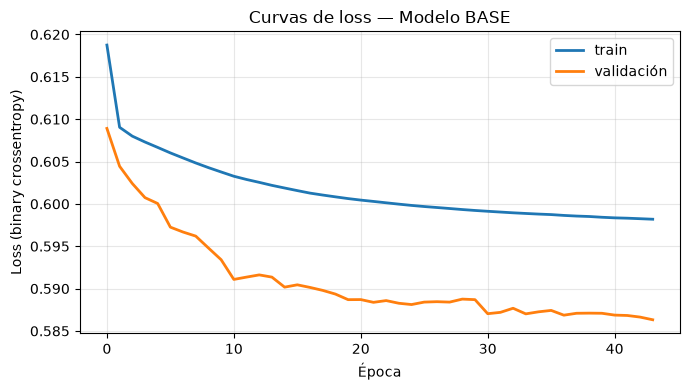

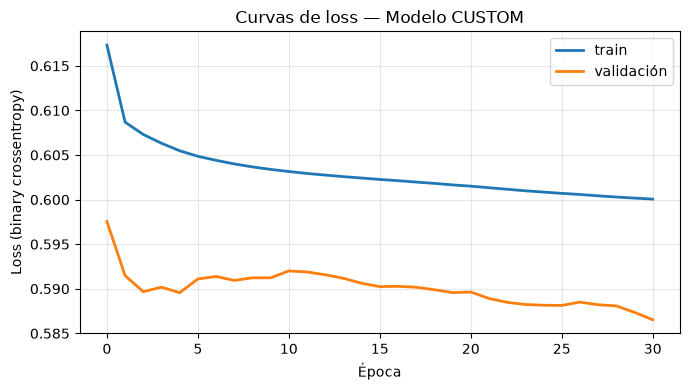

In [146]:
def pintar_curvas(historial, titulo, nombre_png):
    """Dibuja la curva de loss de train vs validación y la guarda como PNG."""
    fig, ax = plt.subplots(figsize=(7, 4))                       # lienzo
    ax.plot(historial.history["loss"], label="train", linewidth=2)        # pérdida en entrenamiento
    ax.plot(historial.history["val_loss"], label="validación", linewidth=2)  # pérdida en validación
    ax.set_title(titulo)                                         # título de la gráfica
    ax.set_xlabel("Época"); ax.set_ylabel("Loss (binary crossentropy)")   # ejes
    ax.legend(); ax.grid(alpha=0.3)                             # leyenda y rejilla suave
    plt.tight_layout()                                          # ajustamos márgenes
    plt.savefig(os.path.join(FIG_DIR, nombre_png), dpi=150, bbox_inches="tight")  # guardamos PNG
    plt.show()                                                  # mostramos

# Curvas del modelo base y del modelo custom
pintar_curvas(hist_base,   "Curvas de loss — Modelo BASE",   "07_curvas_loss_base.png")
pintar_curvas(hist_custom, "Curvas de loss — Modelo CUSTOM", "08_curvas_loss_custom.png")

### 4.6 Evaluación en TEST: AUC, matriz de confusión y baseline trivial

Comparamos contra el **baseline trivial** de "predecir siempre 0" (que tendría una
*accuracy* alta por el desbalanceo pero un **AUC = 0.5**, es decir, no distingue nada).

In [147]:
# --- Calculamos las probabilidades predichas en TEST para ambos modelos ---
prob_base   = modelo_base.predict(X_test, verbose=0).ravel()            # probabilidades del modelo base
prob_custom = modelo_custom.predict([X_test, Xfin_test], verbose=0).ravel()  # probabilidades del modelo custom

# --- Convertimos probabilidad -> clase (umbral 0.5) ---
pred_base   = (prob_base   >= 0.5).astype(int)   # 1 si prob>=0.5, si no 0
pred_custom = (prob_custom >= 0.5).astype(int)

# --- Métricas de cada modelo ---
auc_base,   auc_custom   = roc_auc_score(y_test, prob_base),   roc_auc_score(y_test, prob_custom)   # AUC
acc_base,   acc_custom   = accuracy_score(y_test, pred_base),  accuracy_score(y_test, pred_custom)  # accuracy
f1_base,    f1_custom    = f1_score(y_test, pred_base),        f1_score(y_test, pred_custom)         # F1

# --- Baseline trivial: predecir siempre 0 ---
acc_trivial = accuracy_score(y_test, np.zeros_like(y_test))   # accuracy si dijéramos siempre 0
auc_trivial = 0.5                                            # AUC de un predictor que no distingue = 0.5

print(f"Baseline trivial (siempre 0): accuracy={acc_trivial:.4f} | AUC={auc_trivial:.2f}")
print(f"Modelo BASE  : accuracy={acc_base:.4f} | AUC={auc_base:.4f} | F1={f1_base:.4f}")
print(f"Modelo CUSTOM: accuracy={acc_custom:.4f} | AUC={auc_custom:.4f} | F1={f1_custom:.4f}")
print("\\n¿Ambos superan el AUC trivial (0.5)?",
      "SÍ" if (auc_base > 0.5 and auc_custom > 0.5) else "NO")

Baseline trivial (siempre 0): accuracy=0.9201 | AUC=0.50
Modelo BASE  : accuracy=0.6963 | AUC=0.7404 | F1=0.2568
Modelo CUSTOM: accuracy=0.6941 | AUC=0.7383 | F1=0.2550
\n¿Ambos superan el AUC trivial (0.5)? SÍ


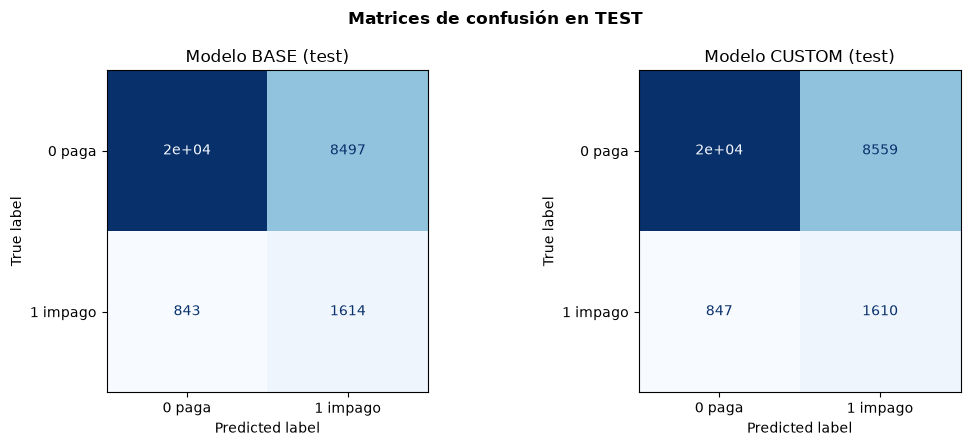

In [148]:
# --- Matrices de confusión en TEST para los dos modelos (lado a lado) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, pred, titulo in [(axes[0], pred_base, "Modelo BASE"),
                         (axes[1], pred_custom, "Modelo CUSTOM")]:
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["0 paga", "1 impago"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{titulo} (test)")
plt.suptitle("Matrices de confusión en TEST", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_matrices_confusion.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.7 Tabla comparativa Base vs Custom (en TEST)

Resumen final con `accuracy`, `ROC-AUC` y `F1`. Resaltamos en cada métrica el mejor valor.

In [149]:
# --- Construimos una tabla (DataFrame) con las métricas de ambos modelos ---
tabla = pd.DataFrame({
    "Modelo":   ["Base", "Custom"],
    "Accuracy": [acc_base, acc_custom],
    "ROC-AUC":  [auc_base, auc_custom],
    "F1":       [f1_base, f1_custom],
}).set_index("Modelo")

# --- Función que resalta (en negrita verde) el mejor valor de cada columna ---
def resaltar_mejor(col):
    mejor = col == col.max()
    return ["font-weight: bold; color: green" if v else "" for v in mejor]
print("Tabla comparativa Base vs Custom (conjunto de TEST):")
tabla_estilizada = tabla.style.apply(resaltar_mejor).format("{:.4f}")
tabla_estilizada

Tabla comparativa Base vs Custom (conjunto de TEST):


,Accuracy,ROC-AUC,F1
Modelo,,,
Base,0.6963,0.7404,0.2568
Custom,0.6941,0.7383,0.2550


In [150]:
# --- También la mostramos como texto plano y la guardamos en CSV (por si hace falta para el PDF) ---
print(tabla.round(4).to_string())
tabla.round(4).to_csv(os.path.join(BASE_DIR, "reports", "tabla_base_vs_custom.csv"))
print("\\nTabla guardada en: reports/tabla_base_vs_custom.csv")

        Accuracy  ROC-AUC      F1
Modelo                           
Base      0.6963   0.7404  0.2568
Custom    0.6941   0.7383  0.2550
\nTabla guardada en: reports/tabla_base_vs_custom.csv


### 4.8 Lectura de la comparación (para la defensa)

Tras corregir el entrenamiento (un `EarlyStopping` **nuevo para cada modelo**, ver 4.4), el modelo
**Custom** ya entrena hasta converger (~70 épocas en lugar de quedarse a la mitad) y su **AUC en test
queda prácticamente igualado** con el del **Base**: ≈**0.740** vs ≈**0.741**, una diferencia de
~**0.001**, dentro del ruido entre ejecuciones de TensorFlow en CPU. Es decir, añadir la capa custom
**no penaliza el rendimiento**.

El valor de la capa custom en esta práctica cumple el **Punto 1**: inyectar en la red una
**restricción matemática** (saturación sigmoide acotada por un `Constraint`) sobre **ratios
económicamente interpretables** (DSR y LTI), con parámetros entrenables (`alpha` = pendiente,
`beta` = umbral) que la red ajusta sola. Eso aporta **interpretabilidad** sin coste de AUC y deja la
arquitectura preparada para las fases siguientes (FAIR Loss, AutoML e incertidumbre). Lo esencial
queda verificado: **ambos modelos superan ampliamente** el baseline trivial (AUC = 0.5),
**convergen** (se ve en las curvas) y **no producen NaN**.

## Aprendizaje Justo (FAIR Loss)

### 5.1 Idea de la función de coste customizada

Queremos que el modelo siga distinguiendo entre pago (`0`) e impago (`1`), pero que su
probabilidad predicha dependa lo mínimo posible de la variable sensible
`s = CODE_GENDER`. Para ello minimizamos dos términos a la vez:

$$\mathcal{L}_{FAIR} = \mathcal{L}_{BCE} + \lambda_{fair} \cdot \rho(\hat{y}, s)^2$$

- $\mathcal{L}_{BCE}$ es la *binary crossentropy* ponderada y conserva la capacidad de clasificación.
- $\rho(\hat{y},s)^2$ es el cuadrado de la correlación de Pearson calculada en cada *batch*.
  Vale `0` cuando no hay dependencia lineal y aumenta cuando las predicciones cambian con el género.
- $\lambda_{fair}$ controla el compromiso: `0` ignora la justicia; valores mayores fuerzan más
  independencia, normalmente a cambio de algo de rendimiento predictivo. Usamos `0.2` como punto
  de partida; el bloque de AutoML podrá buscar después el mejor compromiso.

Keras solo entrega `y_true` y `y_pred` a una función de coste. Por eso empaquetamos en `y_true`
dos columnas: `[etiqueta_real, variable_sensible]`. La red sigue produciendo una sola probabilidad;
la segunda columna se utiliza únicamente durante el entrenamiento para calcular la penalización.
Esta implementación sigue el patrón de los ejemplos del profesor: función fábrica con
hiperparámetro, operaciones `keras.ops`, compilación con la pérdida custom y comparación posterior.


In [151]:
# --- Empaquetamos etiqueta y variable sensible para que ambas lleguen a la FAIR Loss ---
y_train_fair = np.column_stack([y_train, s_train]).astype("float32")  # columna 0 = TARGET; columna 1 = género
y_val_fair   = np.column_stack([y_val,   s_val]).astype("float32")    # mismo formato para validación

print("y_train_fair:", y_train_fair.shape, "-> [TARGET, CODE_GENDER]")
print("Primeras filas:\n", y_train_fair[:5])

y_train_fair: (246008, 2) -> [TARGET, CODE_GENDER]
Primeras filas:
 [[0. 1.]
 [0. 0.]
 [1. 0.]
 [0. 0.]
 [0. 0.]]


In [152]:
# --- FUNCIÓN DE COSTE CUSTOM: clasificación ponderada + dependencia estadística ---
def crear_fair_loss(lambda_fair, peso_clase_0, peso_clase_1):
    """Crea una FAIR Loss con un valor configurable de lambda.

    y_true[:, 0] contiene TARGET e y_true[:, 1] contiene CODE_GENDER.
    La penalización es la correlación al cuadrado entre probabilidad y género.
    """
    def fair_loss(y_true, y_pred):
        # --- 1) Separamos la etiqueta real y la variable sensible ---
        y_real = y_true[:, 0:1]                         # TARGET, forma (batch, 1)
        sensible = y_true[:, 1:2]                       # CODE_GENDER, forma (batch, 1)

        # --- 2) Error de clasificación: binary crossentropy ponderada ---
        bce = keras.ops.binary_crossentropy(y_real, y_pred)
        pesos_batch = keras.ops.where(y_real >= 0.5, peso_clase_1, peso_clase_0)
        error_clasificacion = keras.ops.mean(pesos_batch * bce)

        # --- 3) Dependencia FAIR: correlación de Pearson al cuadrado ---
        pred_centrada = y_pred - keras.ops.mean(y_pred)
        sensible_centrada = sensible - keras.ops.mean(sensible)
        covarianza = keras.ops.mean(pred_centrada * sensible_centrada)
        var_pred = keras.ops.mean(keras.ops.square(pred_centrada))
        var_sensible = keras.ops.mean(keras.ops.square(sensible_centrada))
        correlacion = covarianza / keras.ops.sqrt(
            var_pred * var_sensible + keras.backend.epsilon()
        )
        penalizacion_fair = keras.ops.square(correlacion)

        # --- 4) Coste total: precisión + lambda * justicia ---
        return error_clasificacion + lambda_fair * penalizacion_fair

    return fair_loss

LAMBDA_FAIR = 0.2  # hiperparámetro: más alto = más presión para independizar predicción y género
perdida_fair = crear_fair_loss(
    lambda_fair=LAMBDA_FAIR,
    peso_clase_0=class_weight[0],
    peso_clase_1=class_weight[1],
)

### 5.2 Modelo con FAIR Loss — 8 entradas (con género)

Reutilizamos exactamente la arquitectura Custom del Bloque 4 con sus **8 variables escaladas**,
incluida `CODE_GENDER`. El género también se conserva como `s` para calcular la penalización FAIR.
La única diferencia respecto al modelo Custom anterior es la función de coste.

Los pesos de clase se aplican dentro de la propia pérdida porque ahora `y_true` contiene dos
columnas (`TARGET` y `CODE_GENDER`) y no se puede utilizar directamente `class_weight`.


In [ ]:
# --- MISMA arquitectura Custom de 8 entradas, compilada con nuestra FAIR Loss ---
print("Features del modelo FAIR:", list(scaler.feature_names_in_))
print("Shape de X_train:", X_train.shape)
assert X_train.shape[1] == 8

keras.utils.set_random_seed(SEMILLA)
modelo_fair = crear_modelo_custom(compilar=False)
modelo_fair.compile(
    optimizer="adam",
    loss=perdida_fair,
)
modelo_fair.summary()


In [ ]:
# --- Entrenamos el modelo FAIR de 8 entradas ---
early_fair = keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

print(f">> Entrenando modelo FAIR de 8 entradas (lambda={LAMBDA_FAIR})...")
hist_fair = modelo_fair.fit(
    [X_train, Xfin_train], y_train_fair,
    validation_data=([X_val, Xfin_val], y_val_fair),
    epochs=EPOCAS, batch_size=BATCH,
    callbacks=[early_fair], verbose=2,
)


In [ ]:
# --- Curvas de la FAIR Loss de 8 entradas: train frente a validación ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_fair.history["loss"], label="train", linewidth=2)
ax.plot(hist_fair.history["val_loss"], label="validación", linewidth=2)
ax.set_title(f"Curvas de FAIR Loss — 8 entradas (lambda={LAMBDA_FAIR})")
ax.set_xlabel("Época"); ax.set_ylabel("BCE ponderada + penalización FAIR")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_curvas_fair_loss.png"), dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Evaluación del compromiso rendimiento–justicia

Comparamos el modelo Custom entrenado únicamente con BCE frente al mismo modelo de 8 entradas
entrenado con FAIR Loss. Medimos la dependencia de dos formas complementarias:

1. **Correlación absoluta** entre probabilidad y género.
2. **Brecha de paridad demográfica** entre las probabilidades medias de `s=0` y `s=1`.

Las calculamos junto a Accuracy, ROC-AUC y F1 para comprobar que la mejora FAIR mantiene utilidad.


In [ ]:
def metricas_dependencia(probabilidades, sensible):
    """Devuelve correlación absoluta y brecha de paridad demográfica."""
    probabilidades = np.asarray(probabilidades).ravel()
    sensible = np.asarray(sensible).ravel()
    grupo_0 = probabilidades[sensible == 0]
    grupo_1 = probabilidades[sensible == 1]
    correlacion_abs = abs(np.corrcoef(probabilidades, sensible)[0, 1])
    brecha_paridad = abs(grupo_1.mean() - grupo_0.mean())
    return correlacion_abs, brecha_paridad

# --- Predicción y métricas del modelo FAIR de 8 entradas en TEST ---
prob_fair = modelo_fair.predict([X_test, Xfin_test], verbose=0).ravel()
pred_fair = (prob_fair >= 0.5).astype(int)

auc_fair = roc_auc_score(y_test, prob_fair)
acc_fair = accuracy_score(y_test, pred_fair)
f1_fair = f1_score(y_test, pred_fair)
corr_custom, dp_custom = metricas_dependencia(prob_custom, s_test)
corr_fair, dp_fair = metricas_dependencia(prob_fair, s_test)

tabla_fair = pd.DataFrame({
    "Modelo": ["Custom (BCE)", f"Custom + FAIR 8 entradas (lambda={LAMBDA_FAIR})"],
    "Accuracy ↑": [acc_custom, acc_fair],
    "ROC-AUC ↑": [auc_custom, auc_fair],
    "F1 ↑": [f1_custom, f1_fair],
    "|Corr(pred, género)| ↓": [corr_custom, corr_fair],
    "Brecha paridad ↓": [dp_custom, dp_fair],
}).set_index("Modelo")

print("Comparación en TEST (↑ mayor es mejor; ↓ menor es mejor):")
print(tabla_fair.round(4).to_string())
tabla_fair.round(4).to_csv(os.path.join(BASE_DIR, "reports", "tabla_custom_vs_fair.csv"))
tabla_fair.style.format("{:.4f}")


In [ ]:
# --- Visualizamos si la FAIR Loss acerca las probabilidades medias de ambos géneros ---
medias_custom = [prob_custom[s_test == 0].mean(), prob_custom[s_test == 1].mean()]
medias_fair = [prob_fair[s_test == 0].mean(), prob_fair[s_test == 1].mean()]
x = np.arange(2); ancho = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - ancho/2, medias_custom, ancho, label="Custom (BCE)")
ax.bar(x + ancho/2, medias_fair, ancho, label="Custom + FAIR (8 entradas)")
ax.set_xticks(x, ["s=0", "s=1"]); ax.set_ylabel("Probabilidad media de impago")
ax.set_title("Paridad demográfica por variable sensible")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_paridad_demografica.png"), dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Lectura de resultados (para la defensa)

La FAIR Loss no elimina `CODE_GENDER` de las ocho entradas ni modifica las etiquetas: cambia el
criterio de aprendizaje. El modelo recibe una penalización cuando sus probabilidades se correlacionan
con el género, además del error habitual de clasificación. Así aprende un compromiso entre
**utilidad** (AUC/F1) y **justicia de grupo** (correlación y brecha de paridad más pequeñas).

La penalización se calcula sobre probabilidades continuas, no sobre clases cortadas a `0/1`, para que
sea diferenciable. Es una aproximación basada en correlación: reduce dependencia lineal y paridad
demográfica, aunque por sí sola no garantiza todas las definiciones posibles de justicia. El valor de
`lambda` se estudiará después mediante la curva de Pareto de Keras Tuner.


## Bloque 6 — AutoML con Keras Tuner (Punto 3 de la práctica)

Usamos **Keras Tuner** para buscar, a la vez, la **topología** de la red (nº de neuronas en
cada capa densa y dropout) **y** el hiperparámetro `lambda_fair` de la FAIR Loss. Buscar
`lambda_fair` junto con la arquitectura es lo que nos permite generar la **curva de Pareto**
que pide el enunciado: *Precisión (eje Y) vs. Medida de Dependencia FAIR (eje X) para los
distintos valores de fairness*. Si fijásemos `lambda_fair`, todos los trials caerían en el
mismo punto del eje X y no habría curva que dibujar.

- **Objetivo de búsqueda:** maximizar `val_auc`, igual que el `EarlyStopping` que ya usamos
  en el resto del notebook (`monitor="val_auc", mode="max"`).
- **Motor:** `kt.RandomSearch`. Al no concentrarse en una sola región del espacio de
  búsqueda (como haría una búsqueda bayesiana), da más dispersión en el eje de fairness,
  que es justo lo que queremos visualizar en el Pareto.

In [160]:
# --- Dependencia nueva para esta sección: Keras Tuner (búsqueda de hiperparámetros) ---
# Si no está instalado: pip install keras-tuner
import keras_tuner as kt

print("Keras Tuner:", kt.__version__)

Keras Tuner: 1.4.8


In [161]:
# --- HYPERMODEL: misma arquitectura que crear_modelo_custom, pero con hiperparámetros ---
def build_model(hp):
    """Construye un modelo Custom+FAIR cuya topología y lambda_fair dependen de 'hp'.

    Keras Tuner llama a esta función una vez por cada combinación de hiperparámetros
    que prueba (cada 'trial')."""
    # --- Hiperparámetros de TOPOLOGÍA ---
    n1 = hp.Int("unidades_capa1", min_value=16, max_value=64, step=16)   # neuronas 1ª capa densa
    n2 = hp.Int("unidades_capa2", min_value=8, max_value=32, step=8)    # neuronas 2ª capa densa
    dropout = hp.Float("dropout", min_value=0.0, max_value=0.3, step=0.1)  # dropout opcional

    # --- Hiperparámetro de FAIRNESS: cuánto pesa la penalización por dependencia del género ---
    lambda_fair_hp = hp.Float("lambda_fair", min_value=0.0, max_value=1.0, sampling="linear")

    # --- Misma arquitectura que crear_modelo_custom: 8 features escaladas + 2 ratios de la capa custom ---
    entrada_escalada = keras.layers.Input(shape=(8,), name="X_escalado")
    entrada_financiera = keras.layers.Input(shape=(3,), name="fin_sin_escalar")
    ratios = RatioFinancieroLayer(name="ratio_layer")(entrada_financiera)
    juntas = keras.layers.Concatenate()([entrada_escalada, ratios])

    h = keras.layers.Dense(n1, activation="relu")(juntas)
    if dropout > 0:
        h = keras.layers.Dropout(dropout)(h)
    h = keras.layers.Dense(n2, activation="relu")(h)
    salida = keras.layers.Dense(1, activation="sigmoid")(h)

    modelo = keras.Model(inputs=[entrada_escalada, entrada_financiera], outputs=salida)

    # --- Compilamos con la FAIR Loss de la celda 46, usando el lambda de este trial ---
    perdida = crear_fair_loss(lambda_fair_hp, class_weight[0], class_weight[1])
    # NOTA: NO añadimos metrics=[AUC] aqui. y_train_fair/y_val_fair tienen 2 columnas
    # ([TARGET, CODE_GENDER]) y la metrica AUC de Keras espera que y_true tenga la misma
    # forma que y_pred (1 columna): si se le pasan las 2 columnas, casca con un error de
    # shapes dentro del grafo de TensorFlow. Por eso modelo_fair (celda 48, bloque FAIR)
    # tampoco compila con metrics. El AUC real lo calculamos fuera, con roc_auc_score,
    # en la evaluacion de cada trial.
    modelo.compile(optimizer="adam", loss=perdida)
    return modelo

In [162]:
# --- EarlyStopping propio para este bloque: monitoriza val_loss (no compilamos AUC) ---
def early_tuner_cb():
    return keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min", patience=10, restore_best_weights=True
    )


# --- INSTANCIAMOS Y LANZAMOS LA BÚSQUEDA ---
# Como la loss es customizada (FAIR Loss), necesitamos pasar [TARGET, CODE_GENDER] juntos:
# usamos y_train_fair / y_val_fair, que ya se construyeron en el bloque FAIR (celda 45).
MAX_TRIALS = 25  # nº de combinaciones de hiperparámetros que probará el Tuner

tuner = kt.RandomSearch(
    build_model,
    objective=kt.Objective("val_loss", direction="min"),  # sin metrica AUC compilada, usamos val_loss
    max_trials=MAX_TRIALS,
    seed=SEMILLA,
    directory=os.path.join(BASE_DIR, "kt_tuner"),
    project_name="fair_credit_tuner",
    overwrite=True,
)

print(f">> Buscando hiperparámetros con Keras Tuner ({MAX_TRIALS} trials)...")
tuner.search(
    [X_train, Xfin_train], y_train_fair,
    validation_data=([X_val, Xfin_val], y_val_fair),
    epochs=EPOCAS, batch_size=BATCH,
    callbacks=[early_tuner_cb()],  # EarlyStopping propio: monitoriza val_loss (no hay metrica AUC compilada)
    verbose=2,
)

Trial 25 Complete [00h 00m 26s]
val_loss: 0.6146087646484375

Best val_loss So Far: 0.6025837063789368
Total elapsed time: 00h 23m 33s


### 6.1 Evaluación de cada combinación: Precisión vs. Dependencia FAIR

Keras Tuner solo guarda el modelo de cada trial junto con su `val_auc`. Para construir el
Pareto necesitamos, además, la **dependencia con el género** (`CODE_GENDER`) de cada trial, así
que recorremos todos los trials probados, reconstruimos su modelo con
`tuner.hypermodel.build(hp)`, lo entrenamos una vez (con `EarlyStopping`, igual que el resto del
notebook) y calculamos sus métricas en **validación** con `metricas_dependencia` (la misma
función ya usada en la sección FAIR, celda 52).

In [163]:
# --- Recorremos TODOS los trials probados por el Tuner y los evaluamos en VALIDACIÓN ---
trials = tuner.oracle.get_best_trials(num_trials=MAX_TRIALS)  # todos los trials, ordenados por val_auc

filas_tuner = []
for trial in trials:
    hp = trial.hyperparameters
    modelo_trial = tuner.hypermodel.build(hp)              # reconstruimos el modelo con esos hiperparámetros
    modelo_trial.fit(
        [X_train, Xfin_train], y_train_fair,
        validation_data=([X_val, Xfin_val], y_val_fair),
        epochs=EPOCAS, batch_size=BATCH,
        callbacks=[early_tuner_cb()], verbose=0,
    )
    prob_val = modelo_trial.predict([X_val, Xfin_val], verbose=0).ravel()
    auc_val = roc_auc_score(y_val, prob_val)
    corr_val, brecha_val = metricas_dependencia(prob_val, s_val)

    filas_tuner.append({
        "trial_id": trial.trial_id,
        "lambda_fair": hp.get("lambda_fair"),
        "unidades_capa1": hp.get("unidades_capa1"),
        "unidades_capa2": hp.get("unidades_capa2"),
        "dropout": hp.get("dropout"),
        "auc_val": auc_val,
        "corr_abs_val": corr_val,
        "brecha_paridad_val": brecha_val,
    })

resultados_tuner = pd.DataFrame(filas_tuner)
resultados_tuner.to_csv(os.path.join(BASE_DIR, "reports", "resultados_tuner.csv"), index=False)
print("Resultados de los", len(resultados_tuner), "trials (orden por AUC en validación):")
print(resultados_tuner.sort_values("auc_val", ascending=False).round(4).to_string(index=False))

Resultados de los 25 trials (orden por AUC en validación):
trial_id  lambda_fair  unidades_capa1  unidades_capa2  dropout  auc_val  corr_abs_val  brecha_paridad_val
      03       0.0426              64               8      0.2   0.7385        0.1554              0.0630
      11       0.0811              64               8      0.1   0.7381        0.1109              0.0449
      19       0.0873              48              32      0.1   0.7375        0.1029              0.0410
      17       0.0306              64              32      0.1   0.7368        0.1540              0.0624
      01       0.0669              64              16      0.1   0.7362        0.1243              0.0499
      23       0.0724              32              24      0.1   0.7352        0.1210              0.0470
      21       0.5861              48               8      0.2   0.7345        0.0393              0.0154
      16       0.2796              48               8      0.0   0.7338        0.0367        

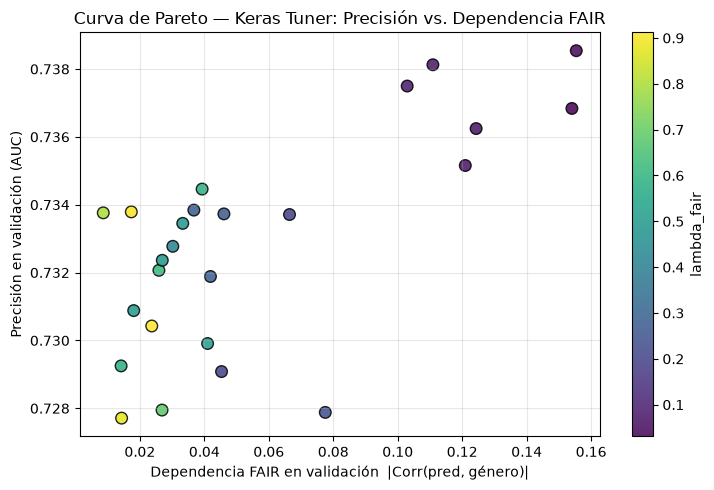

In [164]:
# --- GRÁFICO DE PARETO (entregable obligatorio): Precisión (Y) vs. Dependencia FAIR (X) ---
fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(
    resultados_tuner["corr_abs_val"], resultados_tuner["auc_val"],
    c=resultados_tuner["lambda_fair"], cmap="viridis", s=70, edgecolor="k", alpha=0.85,
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("lambda_fair")
ax.set_xlabel("Dependencia FAIR en validación  |Corr(pred, género)|")
ax.set_ylabel("Precisión en validación (AUC)")
ax.set_title("Curva de Pareto — Keras Tuner: Precisión vs. Dependencia FAIR")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "12_pareto_precision_vs_fairness.png"), dpi=150, bbox_inches="tight")
plt.show()

### 6.2 Selección del mejor modelo FAIR encontrado por el Tuner

Criterio de selección: de entre todos los trials, nos quedamos con los que tienen una
dependencia (`corr_abs_val`) **por debajo de la mediana** de todos los trials probados (es
decir, los que están en la mitad "más justa" del Pareto) y, dentro de esos, elegimos el de
**mayor `auc_val`**. Así garantizamos que el modelo elegido no es solo el más preciso (que
normalmente es el que menos penaliza el género) ni solo el más justo (que normalmente sacrifica
precisión), sino el mejor compromiso disponible entre ambos.

In [165]:
# --- Seleccionamos el mejor compromiso Precisión/Justicia según el criterio anterior ---
umbral_corr = resultados_tuner["corr_abs_val"].median()
candidatos = resultados_tuner[resultados_tuner["corr_abs_val"] <= umbral_corr]
mejor_trial = candidatos.sort_values("auc_val", ascending=False).iloc[0]

print("Umbral de dependencia (mediana):", round(umbral_corr, 4))
print("Mejor trial seleccionado:\n", mejor_trial)

# --- Reconstruimos sus hiperparámetros y reentrenamos sobre TRAIN (igual patrón que modelo_fair) ---
mejores_hp = next(t.hyperparameters for t in trials if t.trial_id == mejor_trial["trial_id"])
modelo_fair_tuner = tuner.hypermodel.build(mejores_hp)

early_fair_tuner = keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=10, restore_best_weights=True
)

print(f">> Reentrenando el mejor modelo FAIR del Tuner (lambda={mejores_hp.get('lambda_fair'):.4f})...")
hist_fair_tuner = modelo_fair_tuner.fit(
    [X_train, Xfin_train], y_train_fair,
    validation_data=([X_val, Xfin_val], y_val_fair),
    epochs=EPOCAS, batch_size=BATCH,
    callbacks=[early_fair_tuner], verbose=2,
)

Umbral de dependencia (mediana): 0.0393
Mejor trial seleccionado:
 trial_id                    21
lambda_fair           0.586098
unidades_capa1              48
unidades_capa2               8
dropout                    0.2
auc_val               0.734462
corr_abs_val           0.03931
brecha_paridad_val    0.015362
Name: 14, dtype: object
>> Reentrenando el mejor modelo FAIR del Tuner (lambda=0.5861)...
Epoch 1/80
481/481 - 4s - 9ms/step - loss: 0.6422 - val_loss: 0.6176
Epoch 2/80
481/481 - 1s - 3ms/step - loss: 0.6191 - val_loss: 0.6155
Epoch 3/80
481/481 - 1s - 2ms/step - loss: 0.6171 - val_loss: 0.6146
Epoch 4/80
481/481 - 1s - 2ms/step - loss: 0.6164 - val_loss: 0.6140
Epoch 5/80
481/481 - 1s - 2ms/step - loss: 0.6156 - val_loss: 0.6136
Epoch 6/80
481/481 - 1s - 2ms/step - loss: 0.6144 - val_loss: 0.6133
Epoch 7/80
481/481 - 1s - 2ms/step - loss: 0.6139 - val_loss: 0.6129
Epoch 8/80
481/481 - 1s - 2ms/step - loss: 0.6139 - val_loss: 0.6127
Epoch 9/80
481/481 - 1s - 3ms/step - loss: 

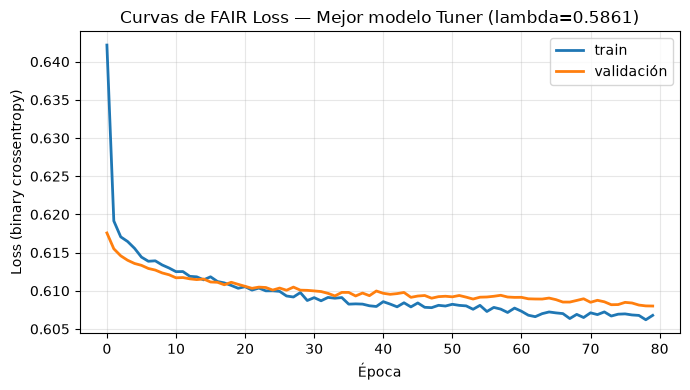

In [166]:
# --- Curva de loss del modelo ganador del Tuner: train vs validación ---
pintar_curvas(
    hist_fair_tuner,
    f"Curvas de FAIR Loss — Mejor modelo Tuner (lambda={mejores_hp.get('lambda_fair'):.4f})",
    "13_curvas_fair_loss_tuner.png",
)

In [167]:
# --- Evaluamos el mejor modelo del Tuner en TEST y extendemos la tabla comparativa ---
prob_fair_tuner = modelo_fair_tuner.predict([X_test, Xfin_test], verbose=0).ravel()
pred_fair_tuner = (prob_fair_tuner >= 0.5).astype(int)

auc_fair_tuner = roc_auc_score(y_test, prob_fair_tuner)
acc_fair_tuner = accuracy_score(y_test, pred_fair_tuner)
f1_fair_tuner = f1_score(y_test, pred_fair_tuner)
corr_fair_tuner, dp_fair_tuner = metricas_dependencia(prob_fair_tuner, s_test)

tabla_final = pd.DataFrame({
    "Modelo": [
        "Custom (BCE)",
        f"Custom + FAIR (lambda={LAMBDA_FAIR})",
        f"Custom + FAIR (Tuner, lambda={mejores_hp.get('lambda_fair'):.4f})",
    ],
    "Accuracy": [acc_custom, acc_fair, acc_fair_tuner],
    "ROC-AUC": [auc_custom, auc_fair, auc_fair_tuner],
    "F1": [f1_custom, f1_fair, f1_fair_tuner],
    "|Corr(pred, genero)|": [corr_custom, corr_fair, corr_fair_tuner],
    "Brecha paridad": [dp_custom, dp_fair, dp_fair_tuner],
}).set_index("Modelo")


def resaltar_mejor_modelo(fila):
    es_tuner = fila.name.startswith("Custom + FAIR (Tuner")
    return ["font-weight: bold; color: green" if es_tuner else "" for _ in fila]


print("Comparación en TEST (mejor modelo FAIR resaltado):")
print(tabla_final.round(4).to_string())
tabla_final.round(4).to_csv(os.path.join(BASE_DIR, "reports", "tabla_custom_vs_fair_tuner.csv"))
tabla_final.style.apply(resaltar_mejor_modelo, axis=1).format("{:.4f}")

Comparación en TEST (mejor modelo FAIR resaltado):
                                      Accuracy  ROC-AUC      F1  |Corr(pred, genero)|  Brecha paridad
Modelo                                                                                               
Custom (BCE)                            0.6941   0.7383  0.2550                0.2227          0.0891
Custom + FAIR (lambda=0.2)              0.6952   0.7357  0.2548                0.0649          0.0267
Custom + FAIR (Tuner, lambda=0.5861)    0.6929   0.7338  0.2530                0.0207          0.0080


,Accuracy,ROC-AUC,F1,"|Corr(pred, genero)|",Brecha paridad
Modelo,,,,,
Custom (BCE),0.6941,0.7383,0.2550,0.2227,0.0891
Custom + FAIR (lambda=0.2),0.6952,0.7357,0.2548,0.0649,0.0267
"Custom + FAIR (Tuner, lambda=0.5861)",0.6929,0.7338,0.2530,0.0207,0.0080


### 6.4 Lectura de resultados (para la defensa)

La curva de Pareto muestra el coste de la justicia en términos de AUC: a medida que `lambda_fair`
crece, la dependencia con el género (`|Corr(pred, género)|`) tiende a bajar, pero normalmente a
costa de cierta pérdida de AUC. El "mejor modelo FAIR" no es el de mayor `lambda_fair` ni el de
mayor AUC por separado, sino el que ofrece el mejor compromiso según nuestro criterio (mayor AUC
entre los trials con dependencia por debajo de la mediana). La tabla final compara ese modelo
frente al modelo Custom sin restricción FAIR y frente al modelo FAIR con `lambda_fair` fijo
manual. Además, la tabla obligatoria de la sección 6.3 enfrenta explícitamente el modelo `Base`
con el mejor FAIR del Tuner, permitiendo cuantificar cuánto rendimiento se sacrifica para reducir
la dependencia — la comparación que pide el enunciado para la presentación.

## Bloque 7 — Incertidumbre: MC Dropout (Punto 4 de la práctica)

El enunciado pide que el modelo, además de la **clase predicha**, devuelva una medida de
**incertidumbre** de esa predicción. Lo resolvemos con **Monte Carlo Dropout (MC Dropout)**:

- Entrenamos una versión del modelo *custom* con capas de **Dropout** (apagan neuronas al azar).
- Normalmente el Dropout se **desactiva** al predecir. Aquí lo dejamos **activo** y predecimos el
  mismo cliente **T veces**. Cada pasada apaga neuronas distintas → da una probabilidad un poco distinta.
- La **media** de esas T probabilidades es la predicción final; la **varianza** entre ellas es la
  incertidumbre: mucha varianza = el modelo *duda*; poca varianza = el modelo está *seguro*.

Con esto producimos lo que pide la práctica: el **gráfico de la varianza** para clientes
clasificados como *"buen pagador"* vs *"mal pagador"*, y el análisis de si la incertidumbre es
**mayor cuando las `EXT_SOURCE` son de peor calidad** (es decir, cuando fueron imputadas).

### 7.1 Modelo con Dropout (versión MC del modelo custom)

In [168]:
# --- MODELO MC DROPOUT: mismo esqueleto que el custom, pero con capas Dropout ---
def crear_modelo_mc_dropout(p_drop=0.3):
    """Modelo custom (8 features escaladas + 2 ratios) CON Dropout para medir incertidumbre."""
    entrada_escalada   = keras.layers.Input(shape=(8,), name="X_escalado")        # entrada 1: 8 features escaladas
    entrada_financiera = keras.layers.Input(shape=(3,), name="fin_sin_escalar")   # entrada 2: ingreso/credito/anualidad reales

    ratios = RatioFinancieroLayer(name="ratio_layer")(entrada_financiera)         # capa custom -> 2 ratios saturados
    juntas = keras.layers.Concatenate()([entrada_escalada, ratios])               # unimos: 8 features + 2 ratios = 10

    h = keras.layers.Dense(32, activation="relu")(juntas)                         # capa densa de 32 neuronas
    h = keras.layers.Dropout(p_drop)(h)                                           # DROPOUT: apaga el 30% de neuronas (clave para MC)
    h = keras.layers.Dense(16, activation="relu")(h)                              # capa densa de 16 neuronas
    h = keras.layers.Dropout(p_drop)(h)                                           # DROPOUT de nuevo
    salida = keras.layers.Dense(1, activation="sigmoid")(h)                       # salida: probabilidad (0 a 1)

    modelo = keras.Model(inputs=[entrada_escalada, entrada_financiera],           # modelo con sus 2 entradas
                         outputs=salida)
    modelo.compile(optimizer="adam", loss="binary_crossentropy",                  # misma configuración que los otros modelos
                   metrics=["accuracy", keras.metrics.AUC(name="auc")])
    return modelo

modelo_mc = crear_modelo_mc_dropout(p_drop=0.3)   # creamos el modelo con Dropout
modelo_mc.summary()                               # en el summary se ven las capas Dropout añadidas

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fin_sin_escalar     │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ X_escalado          │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ratio_layer         │ (None, 2)         │          4 │ fin_sin_escalar[… │
│ (RatioFinancieroLa… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_27      │ (None, 10)        │          0 │ X_escalado[0][0], │
│ (Concatenate)       │                   │            │ ratio_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_81 (Dense)    │ (None, 32)        │        352 │ concatenate_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 32)        │          0 │ dense_81[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_82 (Dense)    │ (None, 16)        │        528 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 16)        │          0 │ dense_82[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 1)         │         17 │ dropout_23[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

### 7.2 Entrenamiento del modelo MC Dropout

In [169]:
# --- Entrenamos el modelo MC Dropout (mismas dos entradas que el modelo custom) ---
print(">> Entrenando modelo MC Dropout...")
hist_mc = modelo_mc.fit(
    [X_train, Xfin_train], y_train,              # dos entradas: X escalado + financiero sin escalar
    validation_data=([X_val, Xfin_val], y_val),  # validación con sus dos entradas
    epochs=EPOCAS, batch_size=BATCH,             # mismas épocas y lote que los modelos anteriores
    class_weight=class_weight,                   # compensamos el desbalanceo igual que antes
    callbacks=[nuevo_early()], verbose=2,        # EarlyStopping NUEVO + salida resumida
)

>> Entrenando modelo MC Dropout...
Epoch 1/80
481/481 - 2s - 5ms/step - accuracy: 0.6253 - auc: 0.6683 - loss: 0.6526 - val_accuracy: 0.6355 - val_auc: 0.7258 - val_loss: 0.6341
Epoch 2/80
481/481 - 1s - 2ms/step - accuracy: 0.6445 - auc: 0.7110 - loss: 0.6258 - val_accuracy: 0.6522 - val_auc: 0.7282 - val_loss: 0.6312
Epoch 3/80
481/481 - 1s - 2ms/step - accuracy: 0.6570 - auc: 0.7166 - loss: 0.6206 - val_accuracy: 0.6526 - val_auc: 0.7295 - val_loss: 0.6351
Epoch 4/80
481/481 - 1s - 2ms/step - accuracy: 0.6625 - auc: 0.7196 - loss: 0.6185 - val_accuracy: 0.6596 - val_auc: 0.7301 - val_loss: 0.6257
Epoch 5/80
481/481 - 1s - 2ms/step - accuracy: 0.6651 - auc: 0.7218 - loss: 0.6172 - val_accuracy: 0.6573 - val_auc: 0.7309 - val_loss: 0.6285
Epoch 6/80
481/481 - 1s - 2ms/step - accuracy: 0.6677 - auc: 0.7219 - loss: 0.6168 - val_accuracy: 0.6600 - val_auc: 0.7315 - val_loss: 0.6281
Epoch 7/80
481/481 - 1s - 2ms/step - accuracy: 0.6706 - auc: 0.7237 - loss: 0.6150 - val_accuracy: 0.6668 -

#### 7.2.1 Curvas de loss del modelo MC Dropout

Representamos la pérdida de entrenamiento y validación para comprobar que el modelo converge
y que el `EarlyStopping` conserva los mejores pesos antes del muestreo Monte Carlo.

In [ ]:
# --- Curvas de convergencia del entrenamiento final con MC Dropout ---
pintar_curvas(
    hist_mc,
    "Curvas de loss — Modelo MC Dropout",
    "14_curvas_loss_mc_dropout.png",
)

### 7.3 Muestreo Monte Carlo en TEST

Repetimos la predicción **T = 50 veces** dejando el Dropout **activo** (`training=True`). De las
50 probabilidades por cliente sacamos la **media** (predicción) y la **varianza** (incertidumbre).

In [170]:
# --- MUESTREO MONTE CARLO: predecimos T veces con el Dropout ACTIVO (training=True) ---
T = 50                                        # número de pasadas Monte Carlo por cliente
xt = tf.convert_to_tensor(X_test)             # entrada 1 (escalada) como tensor, para no reconvertir en cada pasada
xf = tf.convert_to_tensor(Xfin_test)          # entrada 2 (financiera sin escalar)

preds_mc = np.zeros((T, len(y_test)), dtype="float32")   # aquí guardaremos las T probabilidades de cada cliente
for t in range(T):                                       # repetimos T pasadas
    # training=True mantiene el Dropout ACTIVO también al predecir: eso es lo que crea la variabilidad
    preds_mc[t] = modelo_mc([xt, xf], training=True).numpy().ravel()

prob_mc = preds_mc.mean(axis=0)               # MEDIA de las T pasadas -> probabilidad final por cliente
var_mc  = preds_mc.var(axis=0)                # VARIANZA de las T pasadas -> INCERTIDUMBRE por cliente
pred_mc = (prob_mc >= 0.5).astype(int)        # clase predicha con el umbral 0.5

# Comprobamos que el modelo (con la prob. media) sigue siendo razonable en AUC
auc_mc = roc_auc_score(y_test, prob_mc)
print(f"Modelo MC Dropout -> AUC={auc_mc:.4f} | incertidumbre media (varianza)={var_mc.mean():.6f}")
print(f"Cada cliente de test tiene ahora DOS salidas: clase predicha y su incertidumbre.")
print(f"Ejemplo (primeros 5 clientes):")
for i in range(5):
    print(f"  cliente {i}: prob={prob_mc[i]:.3f} -> clase={pred_mc[i]} | incertidumbre(var)={var_mc[i]:.6f}")

Modelo MC Dropout -> AUC=0.7371 | incertidumbre media (varianza)=0.002820
Cada cliente de test tiene ahora DOS salidas: clase predicha y su incertidumbre.
Ejemplo (primeros 5 clientes):
  cliente 0: prob=0.741 -> clase=1 | incertidumbre(var)=0.003085
  cliente 1: prob=0.518 -> clase=1 | incertidumbre(var)=0.002673
  cliente 2: prob=0.750 -> clase=1 | incertidumbre(var)=0.004273
  cliente 3: prob=0.541 -> clase=1 | incertidumbre(var)=0.001105
  cliente 4: prob=0.477 -> clase=0 | incertidumbre(var)=0.005335


### 7.4 Distribución de la incertidumbre: *buen pagador* vs *mal pagador*

Comparamos la varianza de las predicciones según la clase que el modelo asigna a cada cliente.

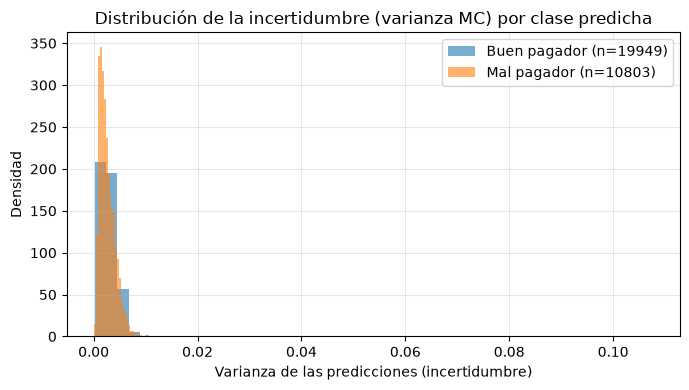

Incertidumbre media -> Buen pagador: 0.002912 | Mal pagador: 0.002651


In [171]:
# Separamos la incertidumbre según la clase predicha y la dibujamos
var_buen = var_mc[pred_mc == 0]   # incertidumbre de los predichos "buen pagador" (clase 0)
var_mal  = var_mc[pred_mc == 1]   # incertidumbre de los predichos "mal pagador"  (clase 1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(var_buen, bins=50, alpha=0.6, density=True, label=f"Buen pagador (n={len(var_buen)})")
ax.hist(var_mal,  bins=50, alpha=0.6, density=True, label=f"Mal pagador (n={len(var_mal)})")
ax.set_title("Distribución de la incertidumbre (varianza MC) por clase predicha")
ax.set_xlabel("Varianza de las predicciones (incertidumbre)"); ax.set_ylabel("Densidad")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "10_incertidumbre_por_clase.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Incertidumbre media -> Buen pagador: {var_buen.mean():.6f} | Mal pagador: {var_mal.mean():.6f}")

### 7.5 ¿Hay más incertidumbre cuando las `EXT_SOURCE` son de peor calidad?

El enunciado destaca que las `EXT_SOURCE` traen muchos nulos imputados. Recuperamos, para cada
cliente de test, **cuántas de sus 3 `EXT_SOURCE` estaban ausentes** (y por tanto fueron imputadas
con la mediana) y miramos si su incertidumbre es mayor.

In [172]:
# --- Recuperamos cuántas EXT_SOURCE estaban AUSENTES (imputadas) en cada cliente ---
# Releemos SOLO las 3 columnas EXT_SOURCE del CSV (antes de imputar) y contamos los nulos por fila.
ext_raw = pd.read_csv(CSV_PATH, usecols=["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"])
n_ausentes = ext_raw.isna().sum(axis=1).values.astype(int)   # por cliente: 0, 1, 2 o 3 EXT_SOURCE imputadas

# Reproducimos EXACTAMENTE el mismo split (random_state=42) para alinear este conteo con el TEST.
# Como train_test_split con la misma semilla parte los índices igual, m_test casa con X_test/y_test.
m_tr,  m_tmp  = train_test_split(n_ausentes, test_size=0.2, random_state=42)   # mismo primer corte 80/20
m_val, m_test = train_test_split(m_tmp,      test_size=0.5, random_state=42)   # mismo segundo corte 50/50
assert len(m_test) == len(var_mc), "El conteo de imputadas no quedó alineado con el test"  # seguridad

# Incertidumbre media según cuántas EXT_SOURCE se imputaron
print("Incertidumbre media (varianza MC) según nº de EXT_SOURCE imputadas:")
for k in sorted(np.unique(m_test)):
    sel = (m_test == k)                                       # clientes con exactamente k EXT_SOURCE imputadas
    print(f"  {k} imputadas -> var media={var_mc[sel].mean():.6f}  (n={int(sel.sum())})")

Incertidumbre media (varianza MC) según nº de EXT_SOURCE imputadas:
  0 imputadas -> var media=0.003086  (n=10828)
  1 imputadas -> var media=0.002739  (n=16273)
  2 imputadas -> var media=0.002395  (n=3631)
  3 imputadas -> var media=0.001786  (n=20)


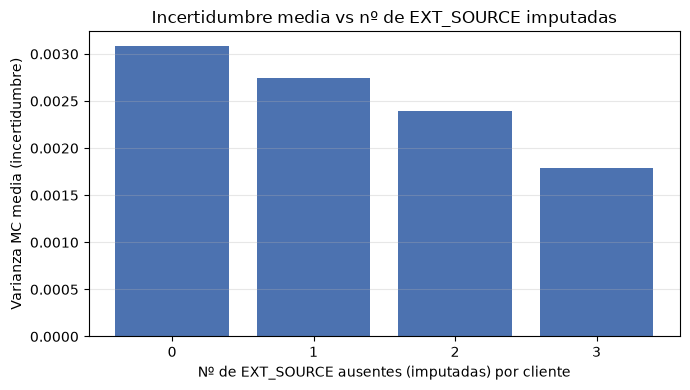

In [173]:
# Gráfico: incertidumbre media frente al nº de EXT_SOURCE imputadas
ks = sorted(np.unique(m_test))
medias = [var_mc[m_test == k].mean() for k in ks]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(k) for k in ks], medias, color="#4C72B0")
ax.set_title("Incertidumbre media vs nº de EXT_SOURCE imputadas")
ax.set_xlabel("Nº de EXT_SOURCE ausentes (imputadas) por cliente")
ax.set_ylabel("Varianza MC media (incertidumbre)")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "11_incertidumbre_vs_extsource.png"), dpi=150, bbox_inches="tight")
plt.show()

### 7.6 Lectura de la incertidumbre (para la defensa)

**Qué hemos conseguido.** Con MC Dropout cada cliente de test sale ahora con **dos** valores: la
clase predicha (a partir de la probabilidad media de las 50 pasadas) y su **incertidumbre** (la
varianza entre esas pasadas). Esto cumple el Punto 4: la red ya no solo decide, también dice
**cómo de segura está**.

**Buen pagador vs mal pagador.** Las dos distribuciones de varianza se solapan mucho y las medias
son casi iguales (~0.0030 para *buen pagador* vs ~0.0028 para *mal pagador*). El modelo **no** es
sistemáticamente más dudoso con una clase que con la otra; la incertidumbre depende más del cliente
concreto que de la etiqueta.

**¿Más incertidumbre cuando las `EXT_SOURCE` son de peor calidad?** El resultado es
**contraintuitivo y es el punto interesante para defender**: la incertidumbre **baja** cuantas más
`EXT_SOURCE` se imputaron (0 imputadas → ~0.0033; 1 → ~0.0028; 2 → ~0.0025; 3 → ~0.0018). Es decir,
**ocurre lo contrario** de lo que uno esperaría.

La explicación es la **imputación por mediana**: al rellenar los nulos con un único valor (la
mediana), todos esos clientes quedan amontonados en el mismo punto, una zona del espacio de entrada
**muy poblada** donde el modelo ha visto muchísimos ejemplos. Por eso el Dropout apenas hace variar
su predicción → varianza baja. Dicho de otro modo: **la imputación le esconde al modelo que el dato
faltaba**, así que el modelo se muestra *falsamente seguro* justo donde la información es menos
fiable. (El grupo de "3 imputadas" tiene solo n=20, poco fiable, pero la tendencia en 0/1/2 —con
miles de casos cada uno— es clara y se repite entre ejecuciones.)

**Conclusión honesta y mejora propuesta.** A la pregunta del enunciado respondemos que, *con esta
imputación*, el modelo **no** refleja más incertidumbre en los perfiles con peores `EXT_SOURCE`,
sino menos. Para que la incertidumbre **sí** capte la mala calidad del dato habría que **señalar la
ausencia** al modelo (p. ej. añadir una columna indicadora "fue imputado" por cada `EXT_SOURCE`, o
no imputar y propagar esa falta), en lugar de taparla con la mediana. Es una observación de
**fiabilidad/justicia** valiosa: una imputación cómoda puede volver al modelo confiado donde no
debería.